# Hallucination Detection with KLE Analysis

## Setup

All numbers below are computed post-hoc from the saved experiment result files under `results/` — no new generation happens in this notebook.

In [1]:
print("hello")

hello


In [ ]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})


def find_repo_root(start=None):
    """Walk up from `start` (default: cwd) until a `.git` directory is found.

    Avoids depending on os.getcwd() matching this notebook's folder — some
    Jupyter front-ends (e.g. VS Code) launch the kernel with cwd set to the
    workspace root instead of the notebook's own directory.
    """
    path = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(path, ".git")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("Could not locate repo root (no .git found above cwd)")
        path = parent


#REPO_ROOT = find_repo_root()
REPO_ROOT = "/Users/fatih/Desktop/master-thesis"
RESULTS_DIR = os.path.join(REPO_ROOT, "results")                    # read-only: saved experiment outputs
THESIS_RESULTS_DIR = os.path.join(REPO_ROOT, "thesis-results")      # everything this notebook writes lives here
TABLES_DIR = os.path.join(THESIS_RESULTS_DIR, "tables")
FIGURES_DIR = os.path.join(THESIS_RESULTS_DIR, "figures")
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

MODEL_TAGS = ["8b", "mistral"]
MODEL_LABELS = {"8b": "Llama-3.1-8B", "mistral": "Mistral-7B"}   # display + CSV `model` column
DATASETS = ["triviaqa", "nqopen", "morehopqa"]
CONDITIONS = ["c1", "c2", "c3", "c4"]
CONDITION_LABELS = {"c1": "C1", "c2": "C2", "c3": "C3", "c4": "C4"}
SIGNALS = ["whitebox", "blackbox"]   # white-box first in every figure and table

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [3]:
def resolve_result_file(cond, signal, dataset, model_tag):
    """Locate a saved C1-C4 result file, handling the naming schemes present in results/."""
    box_dir = "black-box" if signal == "blackbox" else "white-box"
    box_suffix = "BB" if signal == "blackbox" else "WB"
    candidates = [
        os.path.join(RESULTS_DIR, box_dir, dataset, f"{cond}_{dataset}_{model_tag}_{box_suffix}_results.json"),
        os.path.join(RESULTS_DIR, f"{cond}_{dataset}_{model_tag}_{box_suffix}_results.json"),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"No result file for {cond}/{signal}/{dataset}/{model_tag}; tried: {candidates}")


def load_result(cond, signal, dataset, model_tag):
    with open(resolve_result_file(cond, signal, dataset, model_tag), encoding="utf-8") as f:
        return json.load(f)


def auroc_values(cond, signal, dataset, model_tag):
    """Returns (primary_auroc, auroc_max, auroc_mean, auroc_attn_mean, n_questions).

    C1-C3 store a single AUROC float. C4 stores a dict of aggregation
    variants (max/mean/[attn_mean]); "max" is the thesis-stated primary
    strategy, used here as the comparable value across all conditions.
    """
    d = load_result(cond, signal, dataset, model_tag)
    n = len(d["details"])
    if cond == "c4":
        agg = d["auroc"]
        return agg["max"], agg.get("max"), agg.get("mean"), agg.get("attn_mean"), n
    return d["auroc"], None, None, None, n

## 1. AUROC Scores — Black-box vs. White-box, All Conditions, Datasets, Models

One row per (model, dataset, condition, signal). C4 rows also carry every aggregation variant (`auroc_max`, `auroc_mean`, `auroc_attn_mean`); `auroc` is the primary value used for comparison across conditions (max-aggregation for C4).

In [4]:
rows = []
for model_tag in MODEL_TAGS:
    for dataset in DATASETS:
        for cond in CONDITIONS:
            for signal in SIGNALS:
                auroc, auroc_max, auroc_mean, auroc_attn_mean, n = auroc_values(cond, signal, dataset, model_tag)
                rows.append({
                    "model": MODEL_LABELS[model_tag],
                    "dataset": dataset,
                    "condition": CONDITION_LABELS[cond],
                    "signal": signal,
                    "auroc": auroc,
                    "auroc_max": auroc_max,
                    "auroc_mean": auroc_mean,
                    "auroc_attn_mean": auroc_attn_mean,
                    "n_questions": n,
                })

df_auroc = pd.DataFrame(rows)
df_auroc

,model,dataset,condition,signal,auroc,auroc_max,auroc_mean,auroc_attn_mean,n_questions
0,llama31_8b,triviaqa,C1,blackbox,0.843151,NaN,NaN,NaN,1000
1,llama31_8b,triviaqa,C1,whitebox,0.781801,NaN,NaN,NaN,1000
2,llama31_8b,triviaqa,C2,blackbox,0.709474,NaN,NaN,NaN,1000
3,llama31_8b,triviaqa,C2,whitebox,0.691712,NaN,NaN,NaN,1000
4,llama31_8b,triviaqa,C3,blackbox,0.864022,NaN,NaN,NaN,1000
5,llama31_8b,triviaqa,C3,whitebox,0.820879,NaN,NaN,NaN,1000
6,llama31_8b,triviaqa,C4,blackbox,0.677258,0.677258,0.629254,NaN,1000
7,llama31_8b,triviaqa,C4,whitebox,0.784557,0.784557,0.772933,0.785183,1000
8,llama31_8b,nqopen,C1,blackbox,0.727875,NaN,NaN,NaN,1000
9,llama31_8b,nqopen,C1,whitebox,0.739646,NaN,NaN,NaN,1000


In [5]:
csv_path = os.path.join(TABLES_DIR, "auroc_scores.csv")
df_auroc.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/auroc_scores.csv


### Figure — AUROC by condition, grouped by dataset, black-box vs. white-box panels

Layout follows `results/kle_auroc_comparison.ipynb` (Chart 1): x-axis groups by dataset, bars colored by condition (fixed per-condition palette), C4 aggregation variants share the C4 color and are distinguished by hatching. One figure per model.

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auroc_by_condition_8b.png


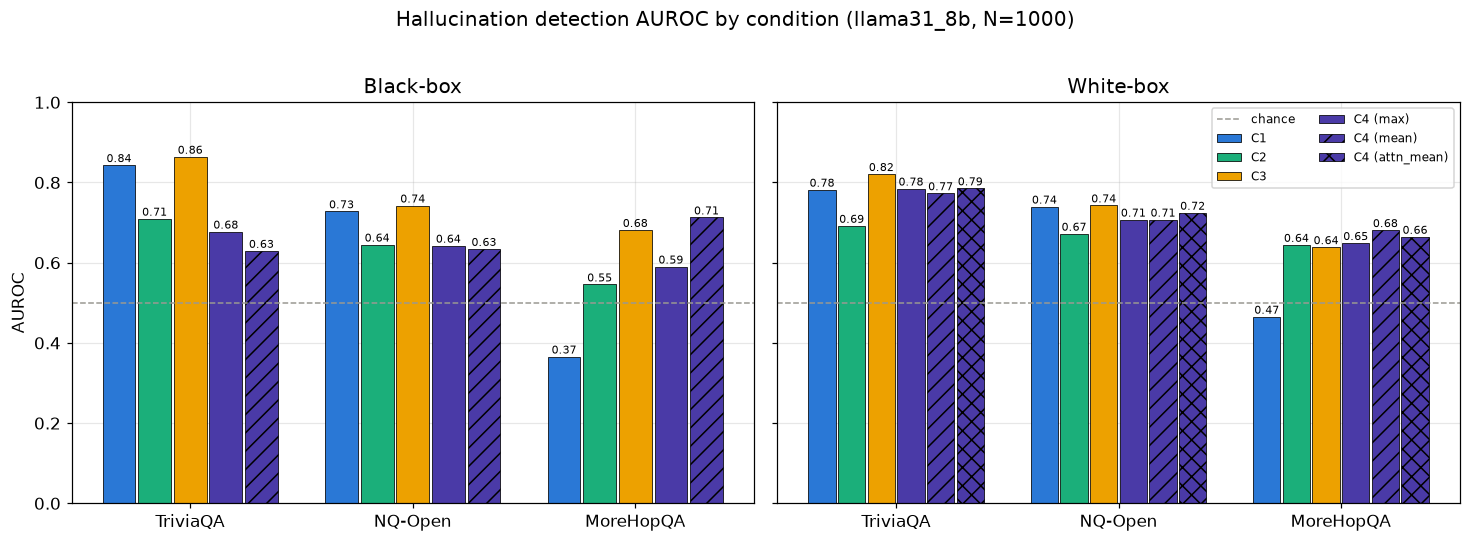

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auroc_by_condition_mistral.png


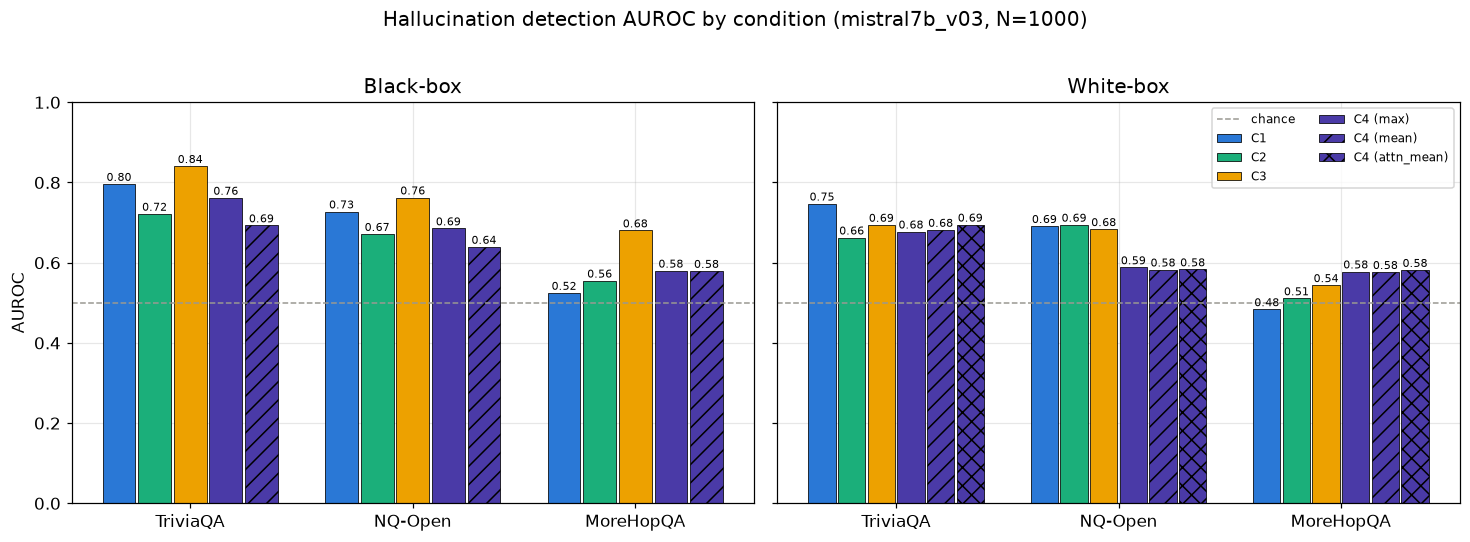

In [6]:
COND_COLORS = {"C1": "#2a78d6", "C2": "#1baf7a", "C3": "#eda100", "C4": "#4a3aa7"}
CHANCE_COLOR = "#9a9992"
SIGNAL_LABELS = {"blackbox": "Black-box", "whitebox": "White-box"}
DATASET_LABELS = {"triviaqa": "TriviaQA", "nqopen": "NQ-Open", "morehopqa": "MoreHopQA"}

# (bar_key, legend_label, hatch) per signal. C4 variants share the C4 color
# and are distinguished by hatch only; attn_mean only exists for white-box.
BARS = {
    "blackbox": [("C1", "C1", ""), ("C2", "C2", ""), ("C3", "C3", ""),
                 ("C4:max", "C4 (max)", ""), ("C4:mean", "C4 (mean)", "//")],
    "whitebox": [("C1", "C1", ""), ("C2", "C2", ""), ("C3", "C3", ""),
                 ("C4:max", "C4 (max)", ""), ("C4:mean", "C4 (mean)", "//"),
                 ("C4:attn_mean", "C4 (attn_mean)", "xx")],
}


def lookup_auroc(df, model_label, dataset, signal, bar_key):
    row = df[(df["model"] == model_label) & (df["dataset"] == dataset) & (df["signal"] == signal)]
    if ":" in bar_key:
        cond, agg = bar_key.split(":")
        col = {"max": "auroc_max", "mean": "auroc_mean", "attn_mean": "auroc_attn_mean"}[agg]
        return row[row["condition"] == cond][col].iloc[0]
    return row[row["condition"] == bar_key]["auroc"].iloc[0]


def plot_auroc_by_condition(df, model_tag, model_label):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
    for ax, signal in zip(axes, SIGNALS):
        bars = BARS[signal]
        k = len(bars)
        w = 0.8 / k
        for j, (bar_key, label, hatch) in enumerate(bars):
            xs = [i + (j - (k - 1) / 2) * w for i in range(len(DATASETS))]
            ys = [lookup_auroc(df, model_label, ds, signal, bar_key) for ds in DATASETS]
            ax.bar(xs, ys, width=w * 0.92, color=COND_COLORS[bar_key.split(":")[0]],
                   edgecolor="black", linewidth=0.5, hatch=hatch, label=label)
            for x, v in zip(xs, ys):
                ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                            xytext=(0, 2), ha="center", fontsize=7)
        ax.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1, label="chance")
        ax.set_xticks(range(len(DATASETS)))
        ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
        ax.set_ylim(0, 1.0)
        ax.set_title(SIGNAL_LABELS[signal])

    axes[0].set_ylabel("AUROC")
    axes[1].legend(loc="upper right", fontsize=8, ncol=2)
    fig.suptitle(f"Hallucination detection AUROC by condition ({model_label}, N=1000)", y=1.02)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, f"auroc_by_condition_{model_tag}.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


for model_tag in MODEL_TAGS:
    plot_auroc_by_condition(df_auroc, model_tag, MODEL_LABELS[model_tag])

## 2. AUROC with 95% Bootstrap Confidence Intervals

Same comparison as Section 1, but drawn as dot-and-whisker: the dot is the AUROC point estimate, the whisker the 95% CI from a nonparametric bootstrap (questions resampled with replacement, B=2000, recomputed from the per-question scores). Layout follows `results/kle_auroc_comparison.ipynb` (Chart 3): same dataset/signal grouping as the Section 1 figure, one figure per model. C4 variants share the C4 color and are distinguished by marker shape instead of hatch (●=max, ■=mean, ▲=attn_mean).

In [7]:
from scipy.stats import rankdata

N_BOOT, BOOTSTRAP_SEED = 2000, 0


def extract_scores(cond, signal, dataset, model_tag, agg_name=None):
    """Per-question uncertainty scores + hallucination labels for one run.

    C1-C3: blackbox uses "kle_full", whitebox uses "vne"; label = judge_correct
    (positive class = hallucination). C4: score is a specific aggregation
    variant (`agg_name`) of the per-question "agg" dict; label is the stored
    "is_halluc".
    """
    d = load_result(cond, signal, dataset, model_tag)
    if cond == "c4":
        det = [r for r in d["details"] if r.get("error") is None and r.get("agg")]
        s = np.array([r["agg"][agg_name] for r in det], dtype=float)
        y = np.array([int(r["is_halluc"]) for r in det], dtype=int)
    else:
        score_key = "kle_full" if signal == "blackbox" else "vne"
        det = d["details"]
        s = np.array([r[score_key] for r in det], dtype=float)
        y = np.array([0 if r["judge_correct"] else 1 for r in det], dtype=int)
    return s, y


def fast_auroc(y, s):
    """Rank-based AUROC (equivalent to sklearn's roc_auc_score, much faster in a bootstrap loop)."""
    r = rankdata(s)
    n1 = int(y.sum())
    n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def bootstrap_ci(y, s, n_boot=N_BOOT, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    out = np.full(n_boot, np.nan)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yb = y[idx]
        if 0 < yb.sum() < n:
            out[b] = fast_auroc(yb, s[idx])
    return np.nanpercentile(out, [2.5, 97.5])


# CI[(model_label, dataset, signal, bar_key)] = (auroc, lo, hi) for every bar in the Section 1 chart
CI = {}
for model_tag in MODEL_TAGS:
    for dataset in DATASETS:
        for signal in SIGNALS:
            for bar_key, _, _ in BARS[signal]:
                cond, _, agg_name = bar_key.partition(":")
                s, y = extract_scores(cond.lower(), signal, dataset, model_tag, agg_name or None)
                auroc, (lo, hi) = fast_auroc(y, s), bootstrap_ci(y, s)
                CI[(MODEL_LABELS[model_tag], dataset, signal, bar_key)] = (auroc, lo, hi)

print(f"Computed {len(CI)} bootstrap CIs (B={N_BOOT}, seed={BOOTSTRAP_SEED})")

Computed 66 bootstrap CIs (B=2000, seed=0)


In [8]:
rows = []
for (model_label, dataset, signal, bar_key), (auroc, lo, hi) in CI.items():
    cond, _, agg = bar_key.partition(":")
    rows.append({
        "model": model_label,
        "dataset": dataset,
        "condition": cond,
        "signal": signal,
        "aggregation": agg or None,
        "auroc": auroc,
        "ci_lo": lo,
        "ci_hi": hi,
        "n_boot": N_BOOT,
        "bootstrap_seed": BOOTSTRAP_SEED,
    })

df_auroc_ci = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "auroc_scores_ci.csv")
df_auroc_ci.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")
df_auroc_ci

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/auroc_scores_ci.csv


,model,dataset,condition,signal,aggregation,auroc,ci_lo,ci_hi,n_boot,bootstrap_seed
0,llama31_8b,triviaqa,C1,blackbox,NaN,0.843151,0.812604,0.870041,2000,0
1,llama31_8b,triviaqa,C2,blackbox,NaN,0.709474,0.665217,0.755029,2000,0
2,llama31_8b,triviaqa,C3,blackbox,NaN,0.864022,0.837827,0.889352,2000,0
3,llama31_8b,triviaqa,C4,blackbox,max,0.677258,0.635721,0.716154,2000,0
4,llama31_8b,triviaqa,C4,blackbox,mean,0.629254,0.588098,0.666264,2000,0
...,...,...,...,...,...,...,...,...,...,...
61,mistral7b_v03,morehopqa,C2,whitebox,NaN,0.511012,0.473970,0.550008,2000,0
62,mistral7b_v03,morehopqa,C3,whitebox,NaN,0.543849,0.497731,0.589727,2000,0
63,mistral7b_v03,morehopqa,C4,whitebox,max,0.577951,0.531523,0.623331,2000,0
64,mistral7b_v03,morehopqa,C4,whitebox,mean,0.576483,0.531294,0.624312,2000,0


Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auroc_by_condition_8b_ci.png


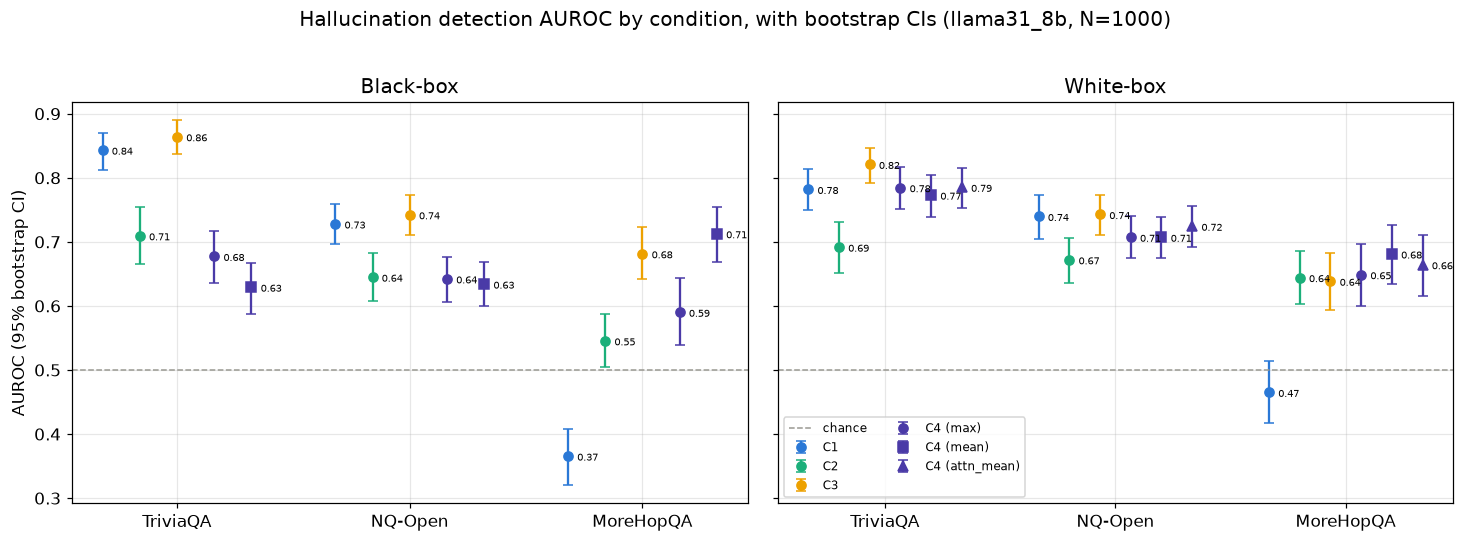

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auroc_by_condition_mistral_ci.png


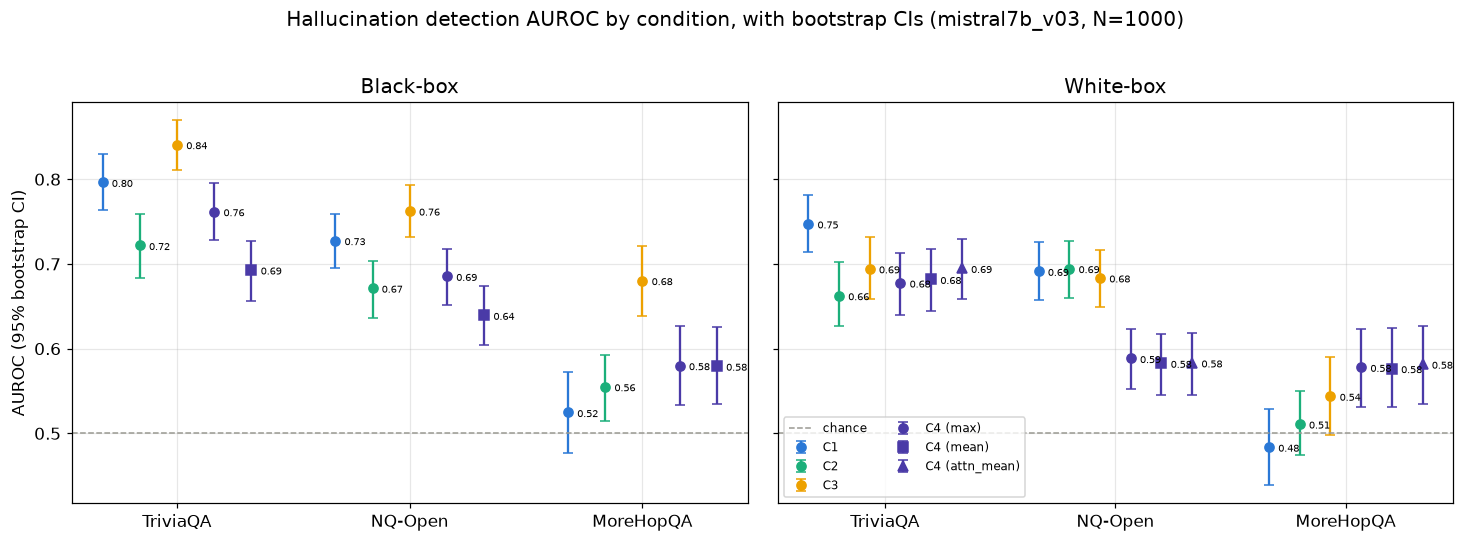

In [9]:
MARKER = {"C1": "o", "C2": "o", "C3": "o", "C4:max": "o", "C4:mean": "s", "C4:attn_mean": "^"}


def plot_auroc_ci(model_tag, model_label):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
    for ax, signal in zip(axes, SIGNALS):
        bars = BARS[signal]
        k = len(bars)
        w = 0.8 / k
        for j, (bar_key, label, _) in enumerate(bars):
            xs = [i + (j - (k - 1) / 2) * w for i in range(len(DATASETS))]
            vals = [CI[(model_label, ds, signal, bar_key)] for ds in DATASETS]
            ys = [v[0] for v in vals]
            yerr = [[v[0] - v[1] for v in vals], [v[2] - v[0] for v in vals]]
            ax.errorbar(xs, ys, yerr=yerr, fmt=MARKER[bar_key], ms=6, capsize=3,
                        lw=1.5, ls="none", color=COND_COLORS[bar_key.split(":")[0]], label=label)
            for x, v in zip(xs, ys):
                ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                            xytext=(6, -3), ha="left", fontsize=6.5)
        ax.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1, label="chance")
        ax.set_xticks(range(len(DATASETS)))
        ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
        ax.set_title(SIGNAL_LABELS[signal])

    axes[0].set_ylabel("AUROC (95% bootstrap CI)")
    axes[1].legend(loc="lower left", fontsize=8, ncol=2)
    fig.suptitle(f"Hallucination detection AUROC by condition, with bootstrap CIs ({model_label}, N=1000)", y=1.02)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, f"auroc_by_condition_{model_tag}_ci.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


for model_tag in MODEL_TAGS:
    plot_auroc_ci(model_tag, MODEL_LABELS[model_tag])

### Figure — C1–C3 only, all models and access methods in one 2×2 panel

The same bootstrap comparison restricted to the three single-score conditions (C1, C2, C3), with C4 and its aggregation variants left out so the panel stays readable. One file instead of one per model: rows = model, columns = access method, x-axis = dataset. Values and intervals are the ones cached in `CI`, so this figure adds no computation.

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auroc_c1c3_by_condition_ci.png


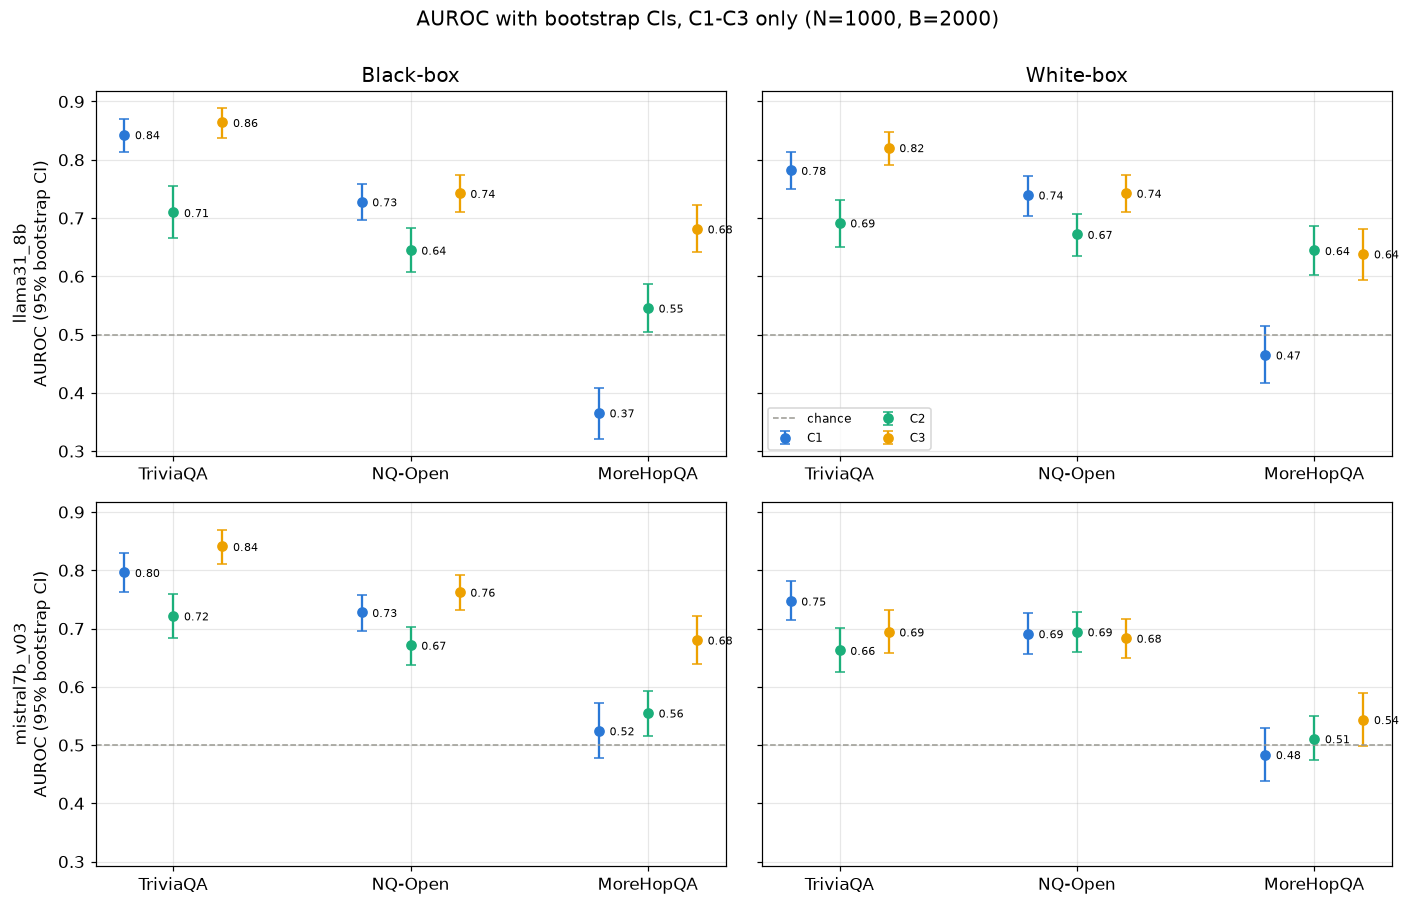

In [10]:
C1C3_CONDS = ["C1", "C2", "C3"]


def plot_auroc_ci_c1c3():
    fig, axes = plt.subplots(len(MODEL_TAGS), len(SIGNALS), figsize=(13, 8.2), sharey=True)
    for i, model_tag in enumerate(MODEL_TAGS):
        model_label = MODEL_LABELS[model_tag]
        for j, signal in enumerate(SIGNALS):
            ax = axes[i, j]
            k = len(C1C3_CONDS)
            w = 0.62 / k
            for m, cond in enumerate(C1C3_CONDS):
                xs = [d + (m - (k - 1) / 2) * w for d in range(len(DATASETS))]
                vals = [CI[(model_label, ds, signal, cond)] for ds in DATASETS]
                ys = [v[0] for v in vals]
                yerr = [[v[0] - v[1] for v in vals], [v[2] - v[0] for v in vals]]
                ax.errorbar(xs, ys, yerr=yerr, fmt="o", ms=6, capsize=3, lw=1.5, ls="none",
                            color=COND_COLORS[cond], label=cond)
                for x, v in zip(xs, ys):
                    ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                                xytext=(7, -3), ha="left", fontsize=7)
            ax.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1,
                       label="chance" if (i == 0 and j == 1) else None)
            ax.set_xticks(range(len(DATASETS)))
            ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
            if i == 0:
                ax.set_title(SIGNAL_LABELS[signal])
            if j == 0:
                ax.set_ylabel(f"{model_label}\nAUROC (95% bootstrap CI)")
    axes[0, 1].legend(fontsize=8, loc="lower left", ncol=2)
    fig.suptitle("AUROC with bootstrap CIs, C1-C3 only (N=1000, B=2000)", y=1.0)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, "auroc_c1c3_by_condition_ci.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


plot_auroc_ci_c1c3()

## 3. C2–C4 vs. External Baselines

AUROC comparison of the CoT conditions against the external baselines. C1 is out of scope here: every baseline scores the **C2 (holistic CoT)** generations, so the comparable KLE conditions are the CoT ones (C1 is covered in Sections 1–2).

Baselines are assigned to a panel by the signal they require, which is exactly the RQ2 split:

| Panel | KLE conditions | External baselines |
|---|---|---|
| Black-box | C2, C3, C4 (black-box KLE) | SelfCheckGPT-NLI, Semantic Entropy (`se_discrete`) |
| White-box | C2, C3, C4 (hidden-state kernel-VNE) | LLM-Check (`logit_entropy`), Semantic Entropy (`se_weighted`) |

`se_discrete` uses cluster proportions only (text-only → black-box); `se_weighted` is the original Rao-Blackwellized estimator and needs token likelihoods (→ white-box side). LLM-Check is plotted with `logit_entropy` (its strongest detector in every cell); all five of its detectors are kept in the CSV.

**Data-source note.** SelfCheckGPT-NLI and Semantic Entropy are derived from the C2 **black-box** logs, LLM-Check from the C2 **white-box** log. Baselines therefore share C2's generations and its hallucination rate exactly, while C3 and C4 have their own generations (rates differ by ~0.02). AUROC is unaffected by that, but the per-row `hallucination_rate` column is reported so the difference is visible.

In [11]:
SELFCHECK_DIR = os.path.join(RESULTS_DIR, "selfcheck-gpt")
LLMCHECK_DIR = os.path.join(RESULTS_DIR, "llm-check")
SE_FILE = os.path.join(RESULTS_DIR, "semantic-entropy", "se_c2_results.json")

LLMCHECK_DETECTORS = ["logit_entropy", "ppl", "window_entropy", "hidden", "attn"]
SE_VARIANTS = ["se_discrete", "se_weighted"]

# Every (method, variant) pair that goes into the CSV. The figures use a subset
# (BASELINE_BARS below); the remaining LLM-Check detectors stay table-only.
BASELINE_VARIANTS = ([("SelfCheckGPT-NLI", None)]
                     + [("LLM-Check", d) for d in LLMCHECK_DETECTORS]
                     + [("SemanticEntropy", v) for v in SE_VARIANTS])


def baseline_scores(method, variant, dataset, model_tag):
    """Per-question baseline scores + hallucination labels for one C2 cell.

    Returns (scores, labels, source_file). Positive class = hallucination, i.e.
    the same orientation as the KLE scores in Section 2. Rows whose scoring
    errored out are dropped (there are none in the current result files).
    """
    if method == "SelfCheckGPT-NLI":
        path = os.path.join(SELFCHECK_DIR, f"selfcheck_c2_{dataset}_{model_tag}_results.json")
        with open(path, encoding="utf-8") as f:
            det = [r for r in json.load(f)["details"] if r.get("error") is None]
        s = np.array([r["score"] for r in det], dtype=float)
    elif method == "LLM-Check":
        path = os.path.join(LLMCHECK_DIR, f"llmcheck_c2_{dataset}_{model_tag}_results.json")
        with open(path, encoding="utf-8") as f:
            det = [r for r in json.load(f)["details"] if r.get("error") is None]
        s = np.array([r["scores"][variant] for r in det], dtype=float)
    elif method == "SemanticEntropy":
        path = SE_FILE
        with open(path, encoding="utf-8") as f:
            det = json.load(f)["cells"][f"c2_{dataset}_{model_tag}"]["details"]
        s = np.array([r[variant] for r in det], dtype=float)
    else:
        raise ValueError(f"Unknown baseline method: {method}")
    y = np.array([int(r["is_halluc"]) for r in det], dtype=int)
    return s, y, path


BASELINE_COLORS = {"SelfCheckGPT-NLI": "#e87ba4", "LLM-Check": "#eb6834", "SemanticEntropy": "#008300"}

# (bar_key, legend_label, hatch) per signal, in plotting order: the CoT KLE
# conditions (all C4 aggregations) followed by the baselines valid for that
# signal. Bar keys are "<method>" or "<method>:<variant>", matching Section 1.
BASELINE_BARS = {
    "blackbox": [("C2", "C2", ""), ("C3", "C3", ""),
                 ("C4:max", "C4 (max)", ""), ("C4:mean", "C4 (mean)", "//"),
                 ("SelfCheckGPT-NLI", "SelfCheckGPT-NLI", ""),
                 ("SemanticEntropy:se_discrete", "Semantic Entropy (discrete)", "")],
    "whitebox": [("C2", "C2", ""), ("C3", "C3", ""),
                 ("C4:max", "C4 (max)", ""), ("C4:mean", "C4 (mean)", "//"),
                 ("C4:attn_mean", "C4 (attn_mean)", "xx"),
                 ("LLM-Check:logit_entropy", "LLM-Check (logit_entropy)", ""),
                 ("SemanticEntropy:se_weighted", "Semantic Entropy (weighted)", "")],
}

KLE_KEYS = {"C2", "C3", "C4:max", "C4:mean", "C4:attn_mean"}


def bar_color(bar_key):
    base = bar_key.split(":")[0]
    return BASELINE_COLORS.get(base, COND_COLORS.get(base))


# CMP[(model_label, dataset, signal, bar_key)] = dict(auroc, ci_lo, ci_hi,
# hallucination_rate, n, source). KLE point estimates and CIs are reused from
# the Section 2 cache; baseline CIs use the identical bootstrap settings.
CMP = {}
for model_tag in MODEL_TAGS:
    model_label = MODEL_LABELS[model_tag]
    for dataset in DATASETS:
        for signal in SIGNALS:
            for bar_key in KLE_KEYS & {k for k, _, _ in BASELINE_BARS[signal]}:
                cond, _, agg_name = bar_key.partition(":")
                s, y = extract_scores(cond.lower(), signal, dataset, model_tag, agg_name or None)
                auroc, lo, hi = CI[(model_label, dataset, signal, bar_key)]
                CMP[(model_label, dataset, signal, bar_key)] = {
                    "auroc": auroc, "ci_lo": lo, "ci_hi": hi,
                    "hallucination_rate": float(y.mean()), "n": len(y),
                    "source": resolve_result_file(cond.lower(), signal, dataset, model_tag),
                }
            for method, variant in BASELINE_VARIANTS:
                # A baseline belongs to exactly one panel (its signal requirement).
                panel = "blackbox" if method in ("SelfCheckGPT-NLI",) or variant == "se_discrete" else "whitebox"
                if panel != signal:
                    continue
                s, y, path = baseline_scores(method, variant, dataset, model_tag)
                lo, hi = bootstrap_ci(y, s)
                CMP[(model_label, dataset, signal, f"{method}:{variant}" if variant else method)] = {
                    "auroc": fast_auroc(y, s), "ci_lo": lo, "ci_hi": hi,
                    "hallucination_rate": float(y.mean()), "n": len(y), "source": path,
                }

print(f"Computed {len(CMP)} entries (B={N_BOOT}, seed={BOOTSTRAP_SEED})")

Computed 102 entries (B=2000, seed=0)


In [12]:
PLOTTED_KEYS = {(signal, key) for signal, bars in BASELINE_BARS.items() for key, _, _ in bars}

rows = []
for (model_label, dataset, signal, bar_key), v in CMP.items():
    method, _, variant = bar_key.partition(":")
    rows.append({
        "model": model_label,
        "dataset": dataset,
        "signal": signal,
        "family": "kle" if bar_key in KLE_KEYS else "baseline",
        "method": method,
        "variant": variant or None,
        "auroc": v["auroc"],
        "ci_lo": v["ci_lo"],
        "ci_hi": v["ci_hi"],
        "hallucination_rate": v["hallucination_rate"],
        "n_questions": v["n"],
        "in_figure": (signal, bar_key) in PLOTTED_KEYS,
        "n_boot": N_BOOT,
        "bootstrap_seed": BOOTSTRAP_SEED,
        "source_file": os.path.relpath(v["source"], REPO_ROOT),
    })

df_baseline_cmp = pd.DataFrame(rows).sort_values(
    ["model", "dataset", "signal", "family", "method", "variant"], na_position="first").reset_index(drop=True)

csv_path = os.path.join(TABLES_DIR, "baseline_comparison_auroc.csv")
df_baseline_cmp.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")
df_baseline_cmp

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/baseline_comparison_auroc.csv


,model,dataset,signal,family,method,variant,auroc,ci_lo,ci_hi,hallucination_rate,n_questions,in_figure,n_boot,bootstrap_seed,source_file
0,llama31_8b,morehopqa,blackbox,baseline,SelfCheckGPT-NLI,NaN,0.501166,0.462315,0.539786,0.714,1000,True,2000,0,results/selfcheck-gpt/selfcheck_c2_morehopqa_8...
1,llama31_8b,morehopqa,blackbox,baseline,SemanticEntropy,se_discrete,0.568126,0.527005,0.607335,0.714,1000,True,2000,0,results/semantic-entropy/se_c2_results.json
2,llama31_8b,morehopqa,blackbox,kle,C2,NaN,0.545577,0.505067,0.587360,0.714,1000,True,2000,0,results/black-box/morehopqa/c2_morehopqa_8b_BB...
3,llama31_8b,morehopqa,blackbox,kle,C3,NaN,0.681401,0.641382,0.722389,0.813,1000,True,2000,0,results/black-box/morehopqa/c3_morehopqa_8b_BB...
4,llama31_8b,morehopqa,blackbox,kle,C4,max,0.590149,0.538488,0.643848,0.846,1000,True,2000,0,results/black-box/morehopqa/c4_morehopqa_8b_BB...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,mistral7b_v03,triviaqa,whitebox,kle,C2,NaN,0.662549,0.626117,0.701692,0.269,1000,True,2000,0,results/white-box/triviaqa/c2_triviaqa_mistral...
98,mistral7b_v03,triviaqa,whitebox,kle,C3,NaN,0.694280,0.658510,0.731239,0.261,1000,True,2000,0,results/white-box/triviaqa/c3_triviaqa_mistral...
99,mistral7b_v03,triviaqa,whitebox,kle,C4,attn_mean,0.694707,0.658319,0.729082,0.285,1000,True,2000,0,results/white-box/triviaqa/c4_triviaqa_mistral...
100,mistral7b_v03,triviaqa,whitebox,kle,C4,max,0.677468,0.640072,0.713108,0.285,1000,True,2000,0,results/white-box/triviaqa/c4_triviaqa_mistral...


### Figure — C2–C4 vs. baselines, grouped by dataset, black-box vs. white-box panels

Same layout as the Section 1/2 figures (x-axis groups by dataset, one figure per model), with the baselines appended to each panel in their own colors. C4 aggregation variants keep the C4 color and are separated by hatch (bars) or marker shape (CI version: ●=max, ■=mean, ▲=attn_mean; ◆=Semantic Entropy). Panel legends differ because the baseline series differ per signal.

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/baseline_comparison_auroc_8b.png


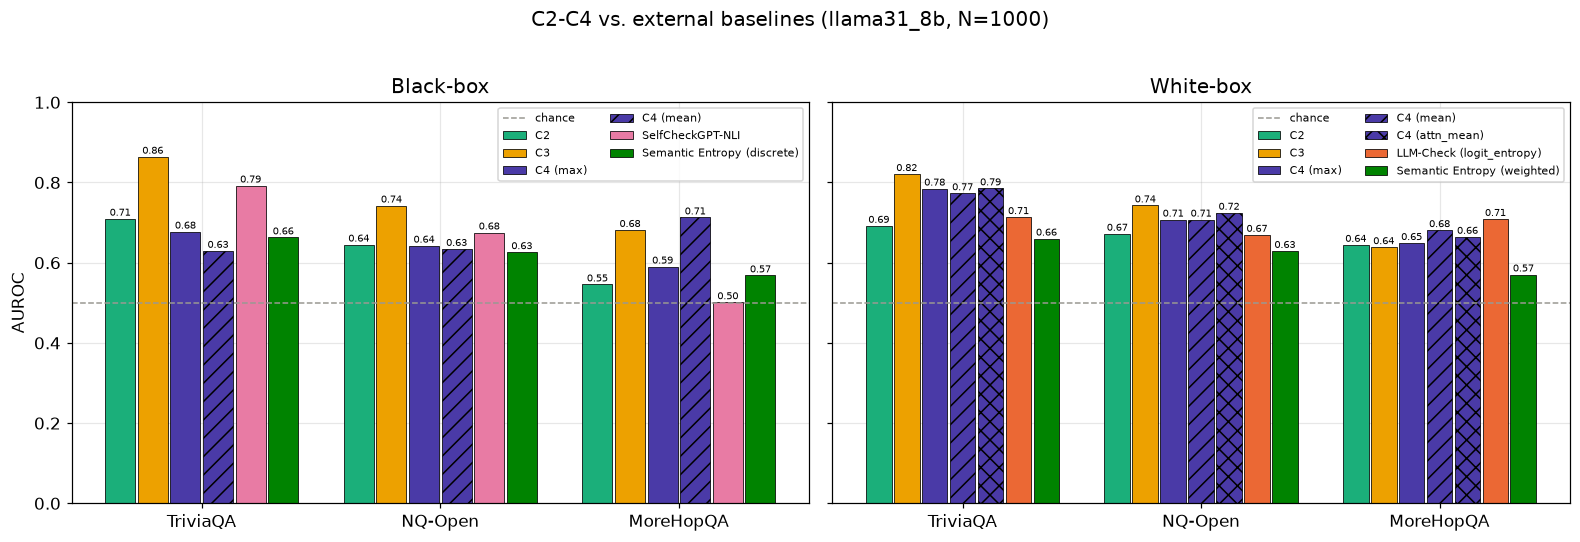

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/baseline_comparison_auroc_mistral.png


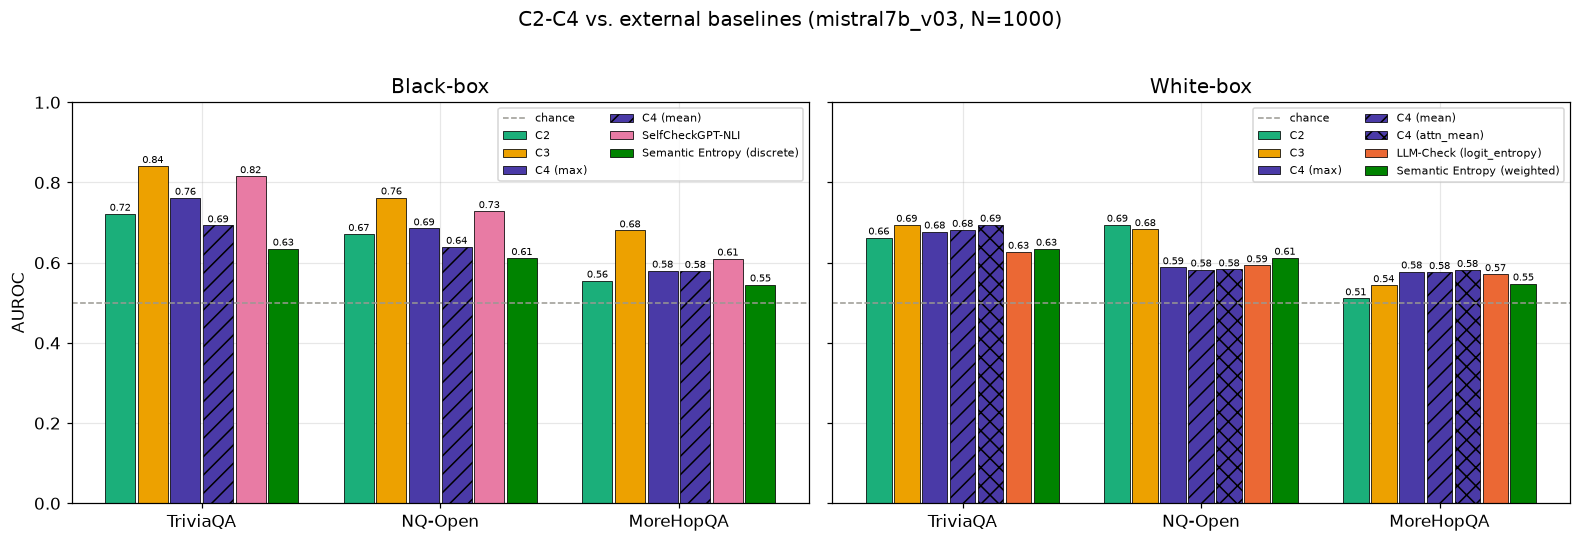

In [13]:
def plot_baseline_comparison(model_tag, model_label):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), sharey=True)
    for ax, signal in zip(axes, SIGNALS):
        bars = BASELINE_BARS[signal]
        k = len(bars)
        w = 0.82 / k
        for j, (bar_key, label, hatch) in enumerate(bars):
            xs = [i + (j - (k - 1) / 2) * w for i in range(len(DATASETS))]
            ys = [CMP[(model_label, ds, signal, bar_key)]["auroc"] for ds in DATASETS]
            ax.bar(xs, ys, width=w * 0.92, color=bar_color(bar_key),
                   edgecolor="black", linewidth=0.5, hatch=hatch, label=label)
            for x, v in zip(xs, ys):
                ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                            xytext=(0, 2), ha="center", fontsize=6.5)
        ax.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1, label="chance")
        ax.set_xticks(range(len(DATASETS)))
        ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
        ax.set_ylim(0, 1.0)
        ax.set_title(SIGNAL_LABELS[signal])
        ax.legend(loc="upper right", fontsize=7.5, ncol=2)  # per-panel: baseline series differ

    axes[0].set_ylabel("AUROC")
    fig.suptitle(f"C2-C4 vs. external baselines ({model_label}, N=1000)", y=1.02)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, f"baseline_comparison_auroc_{model_tag}.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


for model_tag in MODEL_TAGS:
    plot_baseline_comparison(model_tag, MODEL_LABELS[model_tag])

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/baseline_comparison_auroc_8b_ci.png


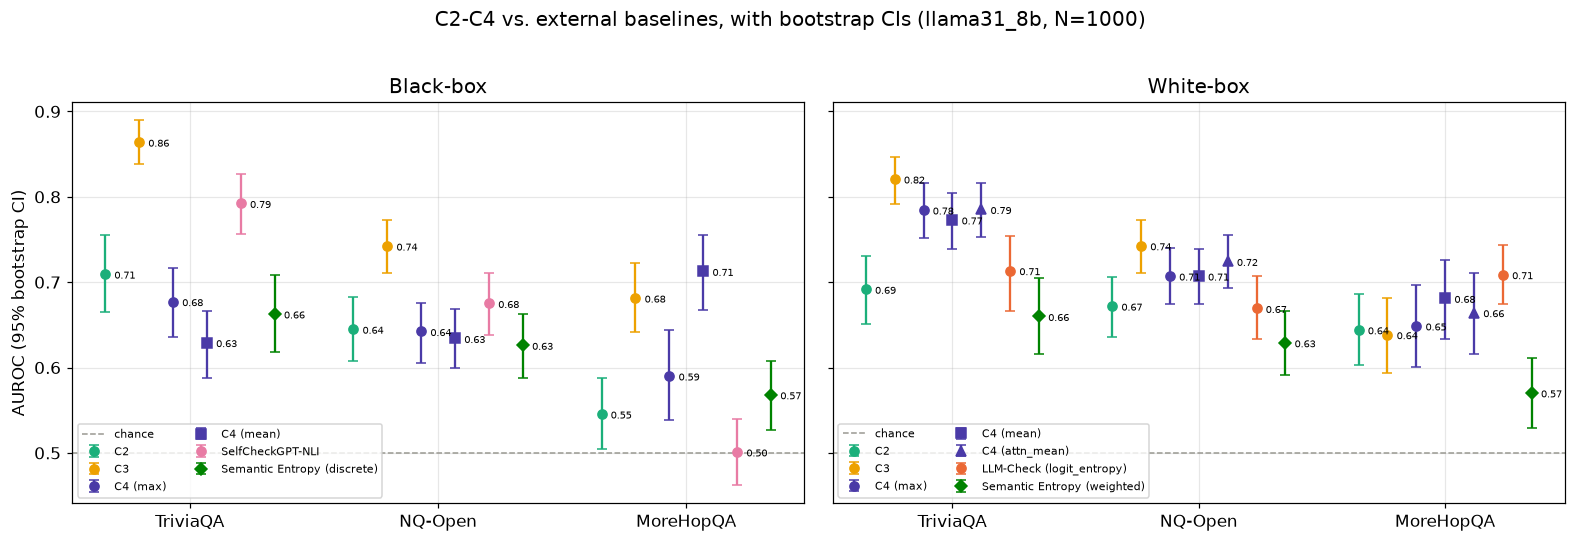

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/baseline_comparison_auroc_mistral_ci.png


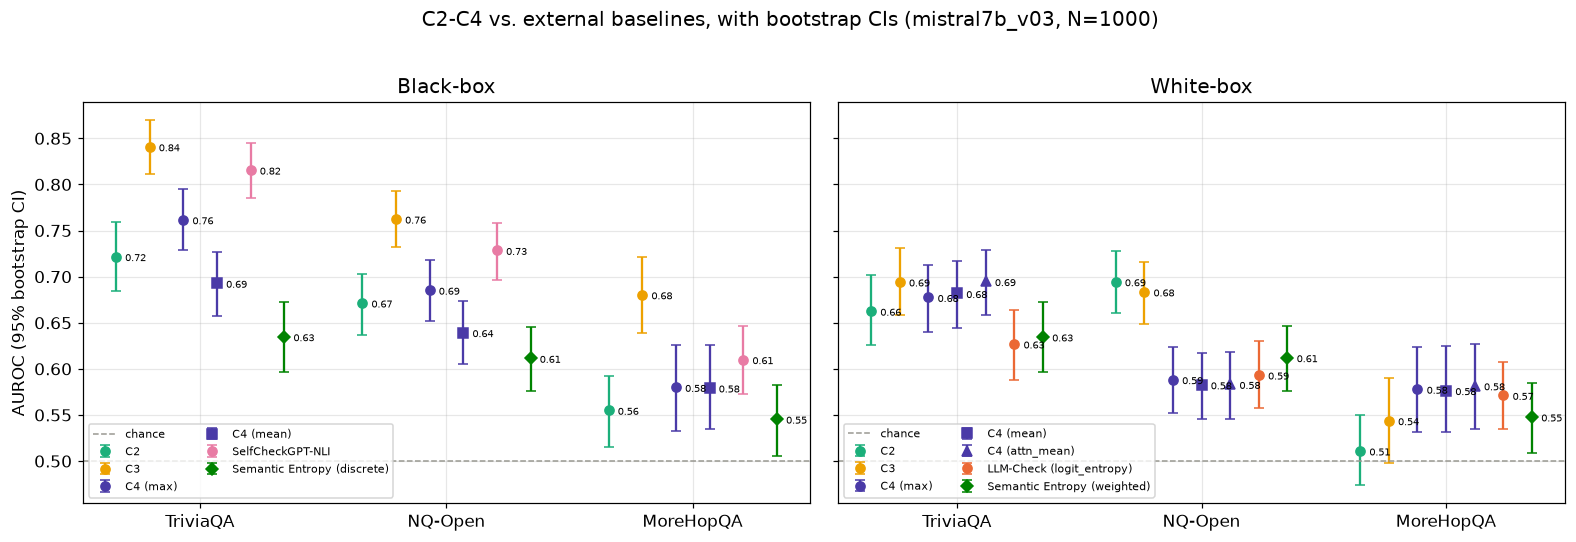

In [14]:
BASELINE_MARKER = {**MARKER, "SelfCheckGPT-NLI": "o", "LLM-Check:logit_entropy": "o",
                   "SemanticEntropy:se_discrete": "D", "SemanticEntropy:se_weighted": "D"}


def plot_baseline_comparison_ci(model_tag, model_label):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), sharey=True)
    for ax, signal in zip(axes, SIGNALS):
        bars = BASELINE_BARS[signal]
        k = len(bars)
        w = 0.82 / k
        for j, (bar_key, label, _) in enumerate(bars):
            xs = [i + (j - (k - 1) / 2) * w for i in range(len(DATASETS))]
            vals = [CMP[(model_label, ds, signal, bar_key)] for ds in DATASETS]
            ys = [v["auroc"] for v in vals]
            yerr = [[v["auroc"] - v["ci_lo"] for v in vals], [v["ci_hi"] - v["auroc"] for v in vals]]
            ax.errorbar(xs, ys, yerr=yerr, fmt=BASELINE_MARKER[bar_key], ms=6, capsize=3,
                        lw=1.5, ls="none", color=bar_color(bar_key), label=label)
            for x, v in zip(xs, ys):
                ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                            xytext=(6, -3), ha="left", fontsize=6.5)
        ax.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1, label="chance")
        ax.set_xticks(range(len(DATASETS)))
        ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
        ax.set_title(SIGNAL_LABELS[signal])
        ax.legend(loc="lower left", fontsize=7.5, ncol=2)  # per-panel: baseline series differ

    axes[0].set_ylabel("AUROC (95% bootstrap CI)")
    fig.suptitle(f"C2-C4 vs. external baselines, with bootstrap CIs ({model_label}, N=1000)", y=1.02)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, f"baseline_comparison_auroc_{model_tag}_ci.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


for model_tag in MODEL_TAGS:
    plot_baseline_comparison_ci(model_tag, MODEL_LABELS[model_tag])

**Notes — Section 3**

- Baselines and C2 share the same generations and labels, so C2-vs-baseline gaps isolate the *scoring function*; C3/C4 additionally change what is being scored (extracted answer span / per-step chains).
- Semantic Entropy vs. C2 is the cleanest ablation in the whole comparison: same samples, same strict-entailment clustering, only the score differs (cluster-probability entropy instead of the kernel von Neumann entropy).
- Both intervals are unpaired per-run bootstraps; overlapping CIs are *not* a significance test for the paired case (methods sharing C2 generations would need a paired bootstrap).
- The unplotted LLM-Check detectors in the CSV (`hidden`, `attn`) sit below 0.5 in most cells, i.e. the raw scores are inverted under the "higher = more likely hallucination" convention used here; they are reported as stored, without sign flipping.

## 4. C4 Step-Level Analysis — MoreHopQA

MoreHopQA is the only dataset where C4's step structure is actually exercised (chains up to `max_steps=5`), and the only one with a post-hoc error-localization pass (`analysis/c4_error_localization.py`, judge = Llama-3.1-8B, output `*_loc8b_results.json` next to each C4 result file). This section asks two separate questions:

1. **Profile** — how does step uncertainty behave along the chain, and does it differ between hallucinated and correct chains? (from `step_scores` / `step_clusters` in the C4 result files)
2. **Localization** — does the step-wise score point at the step where the reasoning actually breaks first? (from the localization output: gold-hop-derived `first_error_step` vs. the run's `argmax_step`)

**Paired design.** The black-box and white-box C4 runs share *identical* reference chains (the chain is decoded at low temperature with a fixed seed), verified 1000/1000. The gold first-error labels are therefore the same on both sides, and the two panels differ only in the step-uncertainty signal: black-box = semantic-cluster entropy over step continuations, white-box = hidden-state kernel-VNE. That makes this the cleanest RQ2 comparison in the thesis.

**Cohort definitions** (kept identical to the localization script so numbers are comparable):
- *format failure* — a chain the pipeline could not segment into steps (`n_steps <= 1`); excluded from all step-wise statistics and reported separately.
- *located* — hallucinated, non-format-failure chains for which the judge could pin down a first broken hop (`first_error_step is not None`).

In [15]:
C4_DATASET = "morehopqa"
LOC_JUDGE_TAG = "8b"          # judge used by analysis/c4_error_localization.py
C4_MAX_STEPS = 5


def loc_result_path(signal, model_tag):
    """The localization output sits next to the C4 result file it was run on."""
    src = resolve_result_file("c4", signal, C4_DATASET, model_tag)
    return src.replace("_results.json", f"_loc{LOC_JUDGE_TAG}_results.json")


def load_c4_step_records(signal, model_tag):
    """Merge per-question C4 step scores with the localization judgements.

    The `format_failure` flag is taken from the localization output rather than
    re-derived, so every cohort below matches the one the localization summary
    was computed on.
    """
    res = load_result("c4", signal, C4_DATASET, model_tag)
    with open(loc_result_path(signal, model_tag), encoding="utf-8") as f:
        loc = json.load(f)
    loc_by_qid = {r["qid"]: r for r in loc["details"]}

    recs = []
    for r in res["details"]:
        if r.get("error") is not None:
            continue
        lr = loc_by_qid.get(r["qid"], {})
        recs.append({
            "qid": r["qid"],
            "n_steps": r["n_steps"],
            "step_scores": r["step_scores"] or [],
            "step_clusters": r.get("step_clusters"),      # black-box only; None in white-box
            "is_halluc": int(r["is_halluc"]),
            "format_failure": bool(lr.get("format_failure", r["n_steps"] <= 1)),
            "first_error_step": lr.get("first_error_step"),
            "first_error_hop": lr.get("first_error_hop"),
            "argmax_step": lr.get("argmax_step"),
        })
    meta = {"summary": loc["summary"],
            "n_samples": res["config"]["n_samples"],
            "max_steps": res["config"]["max_steps"],
            "source": resolve_result_file("c4", signal, C4_DATASET, model_tag),
            "loc_source": loc_result_path(signal, model_tag)}
    return recs, meta


C4REC, C4META = {}, {}
for model_tag in MODEL_TAGS:
    for signal in SIGNALS:
        C4REC[(model_tag, signal)], C4META[(model_tag, signal)] = load_c4_step_records(signal, model_tag)

# Sanity check for the paired claim: both signals must describe the same chains.
for model_tag in MODEL_TAGS:
    bb = [(r["qid"], r["n_steps"], r["first_error_step"]) for r in C4REC[(model_tag, "blackbox")]]
    wb = [(r["qid"], r["n_steps"], r["first_error_step"]) for r in C4REC[(model_tag, "whitebox")]]
    print(f"{MODEL_LABELS[model_tag]}: black-box and white-box share chains/labels -> {bb == wb} "
          f"({len(bb)} questions)")

llama31_8b: black-box and white-box share chains/labels -> True (1000 questions)
mistral7b_v03: black-box and white-box share chains/labels -> True (1000 questions)


In [16]:
rows = []
for model_tag in MODEL_TAGS:
    for signal in SIGNALS:
        recs = C4REC[(model_tag, signal)]
        meta = C4META[(model_tag, signal)]
        s = meta["summary"]
        valid = [r for r in recs if not r["format_failure"]]
        ns = np.array([r["n_steps"] for r in valid], dtype=float)
        clusters = np.array([c for r in valid if r["step_clusters"] for c in r["step_clusters"]], dtype=float)
        n_clean = sum(1 for r in valid if r["is_halluc"] == 0)
        rows.append({
            "model": MODEL_LABELS[model_tag],
            "dataset": C4_DATASET,
            "signal": signal,
            "n_total": len(recs),
            "n_valid": len(valid),
            "mean_n_steps": ns.mean(),
            "median_n_steps": float(np.median(ns)),
            "min_n_steps": int(ns.min()),
            "max_n_steps": int(ns.max()),
            "cap_hit_rate": float((ns == meta["max_steps"]).mean()),          # chains stopped by max_steps
            "samples_per_step": meta["n_samples"],
            "format_failure_rate": s["n_format_failure"] / s["n_total"],
            "format_failure_halluc_rate": s["format_failure_halluc_rate"],
            # "right answer, broken reasoning": judge found a failed gold hop although
            # the final answer was judged correct.
            "clean_flagged_rate": (s["n_clean_flagged"] / n_clean) if n_clean else np.nan,
            "mean_step_clusters": clusters.mean() if clusters.size else np.nan,
            "single_cluster_step_rate": float((clusters == 1).mean()) if clusters.size else np.nan,
            "n_seg_mismatch": s["n_seg_mismatch"],
        })

df_c4_step_diag = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "c4_step_diagnostics_morehopqa.csv")
df_c4_step_diag.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")
df_c4_step_diag

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/c4_step_diagnostics_morehopqa.csv


,model,dataset,signal,n_total,n_valid,mean_n_steps,median_n_steps,min_n_steps,max_n_steps,cap_hit_rate,samples_per_step,format_failure_rate,format_failure_halluc_rate,clean_flagged_rate,mean_step_clusters,single_cluster_step_rate,n_seg_mismatch
0,llama31_8b,morehopqa,blackbox,1000,861,4.859466,5.0,2,5,0.925668,10,0.139,0.992806,0.444444,6.51673,0.027964,0
1,llama31_8b,morehopqa,whitebox,1000,861,4.859466,5.0,2,5,0.925668,10,0.139,0.992806,0.444444,NaN,NaN,0
2,mistral7b_v03,morehopqa,blackbox,1000,977,4.709314,5.0,2,5,0.788127,10,0.023,0.782609,0.785714,6.83221,0.022169,0
3,mistral7b_v03,morehopqa,whitebox,1000,977,4.709314,5.0,2,5,0.788127,10,0.023,0.782609,0.785714,NaN,NaN,0


In [17]:
LABEL_NAMES = {1: "hallucinated", 0: "correct"}

rows = []
for model_tag in MODEL_TAGS:
    for signal in SIGNALS:
        valid = [r for r in C4REC[(model_tag, signal)] if not r["format_failure"]]
        for label in (1, 0):
            sub = [r for r in valid if r["is_halluc"] == label]
            for k in range(C4_MAX_STEPS):
                scores = np.array([r["step_scores"][k] for r in sub if len(r["step_scores"]) > k], dtype=float)
                cl = np.array([r["step_clusters"][k] for r in sub
                               if r["step_clusters"] and len(r["step_clusters"]) > k], dtype=float)
                if scores.size == 0:
                    continue
                rows.append({
                    "model": MODEL_LABELS[model_tag],
                    "dataset": C4_DATASET,
                    "signal": signal,
                    "label": LABEL_NAMES[label],
                    "step_index": k + 1,                       # 1-based for the thesis text
                    "n_chains": int(scores.size),
                    "mean_score": float(scores.mean()),
                    "sem_score": float(scores.std(ddof=1) / np.sqrt(scores.size)) if scores.size > 1 else np.nan,
                    "mean_clusters": float(cl.mean()) if cl.size else np.nan,
                })

df_c4_step_profile = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "c4_step_profile_morehopqa.csv")
df_c4_step_profile.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")
df_c4_step_profile.head(12)

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/c4_step_profile_morehopqa.csv


,model,dataset,signal,label,step_index,n_chains,mean_score,sem_score,mean_clusters
0,llama31_8b,morehopqa,blackbox,hallucinated,1,708,1.589485,0.019308,6.738701
1,llama31_8b,morehopqa,blackbox,hallucinated,2,708,1.563851,0.019171,6.646893
2,llama31_8b,morehopqa,blackbox,hallucinated,3,689,1.510193,0.019816,6.480406
3,llama31_8b,morehopqa,blackbox,hallucinated,4,670,1.505890,0.020645,6.526866
4,llama31_8b,morehopqa,blackbox,hallucinated,5,645,1.607619,0.016299,7.100775
5,llama31_8b,morehopqa,blackbox,correct,1,153,1.517155,0.040240,6.418301
6,llama31_8b,morehopqa,blackbox,correct,2,153,1.361497,0.050149,5.784314
7,llama31_8b,morehopqa,blackbox,correct,3,153,1.260888,0.042458,5.137255
8,llama31_8b,morehopqa,blackbox,correct,4,153,1.269694,0.051610,5.241830
9,llama31_8b,morehopqa,blackbox,correct,5,152,1.395251,0.045041,6.026316


### Figure — step-uncertainty profile along the chain

One panel per signal (the two scores live on different scales, so the y-axes are independent). Color = model, line style = label (solid = hallucinated, dashed = correct), shaded band = ±1 SEM. The question this figure answers: is the C4 signal a *level* difference between hallucinated and correct chains, or a *shape* difference (a spike at the step that goes wrong)?

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/c4_step_profile_morehopqa.png


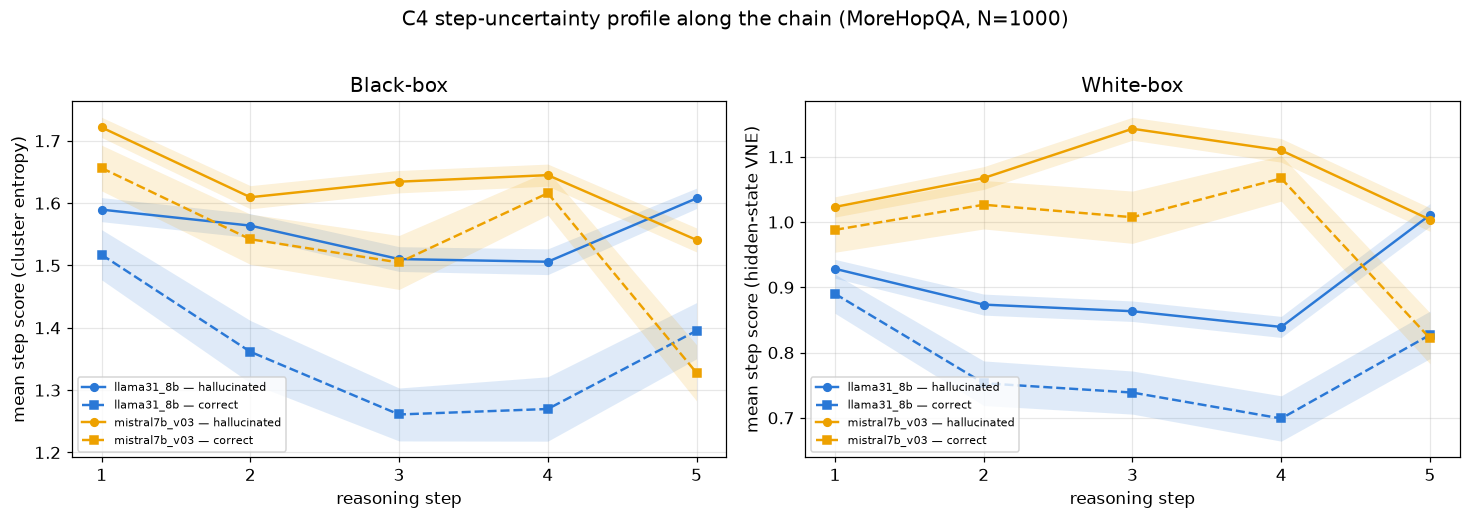

In [18]:
MODEL_COLORS = {"8b": "#2a78d6", "mistral": "#eda100"}
LABEL_STYLE = {"hallucinated": ("-", "o"), "correct": ("--", "s")}


def plot_c4_step_profile():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
    for ax, signal in zip(axes, SIGNALS):
        sub_sig = df_c4_step_profile[(df_c4_step_profile["signal"] == signal)]
        for model_tag in MODEL_TAGS:
            for label, (ls, marker) in LABEL_STYLE.items():
                sub = sub_sig[(sub_sig["model"] == MODEL_LABELS[model_tag]) & (sub_sig["label"] == label)]
                x = sub["step_index"].to_numpy()
                y = sub["mean_score"].to_numpy()
                e = sub["sem_score"].to_numpy()
                ax.plot(x, y, ls=ls, marker=marker, ms=5, lw=1.6, color=MODEL_COLORS[model_tag],
                        label=f"{MODEL_LABELS[model_tag]} — {label}")
                ax.fill_between(x, y - e, y + e, color=MODEL_COLORS[model_tag], alpha=0.15, lw=0)
        ax.set_xticks(range(1, C4_MAX_STEPS + 1))
        ax.set_xlabel("reasoning step")
        ax.set_title(SIGNAL_LABELS[signal])
        ax.legend(fontsize=7.5)

    axes[0].set_ylabel("mean step score (cluster entropy)")
    axes[1].set_ylabel("mean step score (hidden-state VNE)")
    fig.suptitle("C4 step-uncertainty profile along the chain (MoreHopQA, N=1000)", y=1.02)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, "c4_step_profile_morehopqa.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


plot_c4_step_profile()

In [19]:
def localization_stats(recs):
    """Per-chain localization statistics over the *located* cohort.

    All entries are per-chain values whose mean is the reported metric, so a
    single chain-level bootstrap gives CIs for every one of them:
      top1 / pm1     - argmax hits the true first-error step (within +/-0 / +/-1)
      top1_chance /
      pm1_chance     - what a uniformly random step pick scores on the same chain
                       (chains are capped at 5 steps, so raw agreement is
                       unreadable without it)
      auc            - within-chain AUC: P(score at the error step > score at a
                       randomly drawn other step of the same chain); chance 0.5.
                       Cap-safe and paired, unlike top-1 agreement.
      mrr            - reciprocal rank of the error step when steps are sorted by
                       descending score (mrr_chance = its uniform-pick value)
      gap            - score at the error step minus the mean of the other steps
    """
    located = [r for r in recs
               if not r["format_failure"] and r["is_halluc"] == 1
               and r["first_error_step"] is not None and r["argmax_step"] is not None
               and len(r["step_scores"]) > 1 and r["first_error_step"] < len(r["step_scores"])]

    per = {k: [] for k in ["top1", "pm1", "top1_chance", "pm1_chance", "auc",
                           "mrr", "mrr_chance", "gap", "err_step", "argmax_step"]}
    for r in located:
        ss = np.asarray(r["step_scores"], dtype=float)
        e, n = r["first_error_step"], len(r["step_scores"])
        others = np.delete(ss, e)
        per["top1"].append(float(r["argmax_step"] == e))
        per["pm1"].append(float(abs(r["argmax_step"] - e) <= 1))
        per["top1_chance"].append(1.0 / n)
        per["pm1_chance"].append(sum(1 for k in range(n) if abs(k - e) <= 1) / n)
        per["auc"].append(float(((ss[e] > others).sum() + 0.5 * (ss[e] == others).sum()) / others.size))
        per["mrr"].append(1.0 / (1 + int((ss > ss[e]).sum())))
        per["mrr_chance"].append(float(np.mean([1.0 / (k + 1) for k in range(n)])))
        per["gap"].append(float(ss[e] - others.mean()))
        per["err_step"].append(e + 1)
        per["argmax_step"].append(r["argmax_step"] + 1)
    return {k: np.asarray(v, dtype=float) for k, v in per.items()}


def mean_ci(x, n_boot=N_BOOT, seed=BOOTSTRAP_SEED):
    """Point estimate + 95% CI of a mean, bootstrapping over chains."""
    rng = np.random.default_rng(seed)
    n = len(x)
    means = np.array([x[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(means, [2.5, 97.5])
    return float(x.mean()), float(lo), float(hi)


LOC = {}          # (model_tag, signal) -> per-chain stats
LOC_CI = {}       # (model_tag, signal, metric) -> (value, lo, hi)
for model_tag in MODEL_TAGS:
    for signal in SIGNALS:
        st = localization_stats(C4REC[(model_tag, signal)])
        LOC[(model_tag, signal)] = st
        for metric in ["top1", "pm1", "auc", "mrr", "gap"]:
            LOC_CI[(model_tag, signal, metric)] = mean_ci(st[metric])

rows = []
for model_tag in MODEL_TAGS:
    for signal in SIGNALS:
        st = LOC[(model_tag, signal)]
        s = C4META[(model_tag, signal)]["summary"]
        row = {
            "model": MODEL_LABELS[model_tag],
            "dataset": C4_DATASET,
            "signal": signal,
            "n_valid": s["n"],
            "n_halluc": s["n_halluc"],
            "n_located": len(st["top1"]),
            "loc_rate_in_halluc": s["loc_rate_in_halluc"],
            "mean_norm_error_position": s["mean_norm_error_position"],
        }
        for metric, chance in [("top1", st["top1_chance"].mean()),
                               ("pm1", st["pm1_chance"].mean()),
                               ("auc", 0.5),
                               ("mrr", st["mrr_chance"].mean()),
                               ("gap", 0.0)]:
            v, lo, hi = LOC_CI[(model_tag, signal, metric)]
            row[f"{metric}"] = v
            row[f"{metric}_ci_lo"] = lo
            row[f"{metric}_ci_hi"] = hi
            row[f"{metric}_chance"] = chance
            row[f"{metric}_lift"] = v - chance
        row.update({"n_boot": N_BOOT, "bootstrap_seed": BOOTSTRAP_SEED,
                    "loc_source_file": os.path.relpath(C4META[(model_tag, signal)]["loc_source"], REPO_ROOT)})
        rows.append(row)

df_c4_localization = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "c4_error_localization_morehopqa.csv")
df_c4_localization.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")
df_c4_localization[["model", "signal", "n_located", "top1", "top1_chance",
                    "pm1", "pm1_chance", "auc", "mrr", "mrr_chance", "gap"]]

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/c4_error_localization_morehopqa.csv


,model,signal,n_located,top1,top1_chance,pm1,pm1_chance,auc,mrr,mrr_chance,gap
0,llama31_8b,blackbox,597,0.269682,0.215466,0.530988,0.484953,0.518914,0.503741,0.473067,0.049991
1,llama31_8b,whitebox,597,0.201005,0.215466,0.438861,0.484953,0.490089,0.463428,0.473067,0.014765
2,mistral7b_v03,blackbox,735,0.285714,0.216531,0.553741,0.476122,0.556066,0.526939,0.476067,0.097439
3,mistral7b_v03,whitebox,735,0.197279,0.216531,0.453061,0.476122,0.476417,0.457234,0.476067,-0.033695


### Figure — where errors start vs. where uncertainty peaks

Three panels. The first two (one per model) put the *gold* first-error-step distribution next to the step the score actually peaks at, both computed over the same located cohort — if the step score localized errors, the colored bars would track the gray ones. The third panel collects the localization metrics with 95% bootstrap CIs (B=2000, chains resampled); each metric group carries its own chance level as a dashed segment, because top-1 and ±1 chance depend on the chain length (5-step cap) and are nowhere near 0.5.

In [ ]:
GOLD_COLOR = "#9a9992"
SIGNAL_COLORS = {"blackbox": "#2a78d6", "whitebox": "#4a3aa7"}
LOC_METRICS = [("top1", "top-1"), ("pm1", "±1 step"), ("auc", "within-chain AUC")]


def step_share(values):
    """Share of chains per 1-based step index, padded to C4_MAX_STEPS."""
    counts = np.bincount(values.astype(int), minlength=C4_MAX_STEPS + 1)[1:C4_MAX_STEPS + 1]
    return counts / counts.sum()


def plot_c4_localization():
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

    for ax, model_tag in zip(axes[:2], MODEL_TAGS):
        st_bb = LOC[(model_tag, "blackbox")]
        series = [("gold first-error step", step_share(st_bb["err_step"]), GOLD_COLOR)]
        series += [(f"argmax step ({SIGNAL_LABELS[s].lower()})",
                    step_share(LOC[(model_tag, s)]["argmax_step"]), SIGNAL_COLORS[s]) for s in SIGNALS]
        k = len(series)
        w = 0.8 / k
        for j, (label, shares, color) in enumerate(series):
            xs = [i + (j - (k - 1) / 2) * w for i in range(C4_MAX_STEPS)]
            ax.bar(xs, shares, width=w * 0.92, color=color, edgecolor="black", linewidth=0.5, label=label)
        ax.set_xticks(range(C4_MAX_STEPS))
        ax.set_xticklabels(range(1, C4_MAX_STEPS + 1))
        ax.set_xlabel("reasoning step")
        ax.set_title(f"{MODEL_LABELS[model_tag]} (n={len(st_bb['err_step'])} located)")
        ax.legend(fontsize=7.5)
    axes[0].set_ylabel("share of located chains")

    ax = axes[2]
    series = [(model_tag, signal) for model_tag in MODEL_TAGS for signal in SIGNALS]
    k = len(series)
    w = 0.8 / k
    for j, (model_tag, signal) in enumerate(series):
        xs = [i + (j - (k - 1) / 2) * w for i in range(len(LOC_METRICS))]
        vals = [LOC_CI[(model_tag, signal, m)] for m, _ in LOC_METRICS]
        ys = [v[0] for v in vals]
        yerr = [[v[0] - v[1] for v in vals], [v[2] - v[0] for v in vals]]
        ax.errorbar(xs, ys, yerr=yerr, fmt="o" if signal == "blackbox" else "s", ms=6, capsize=3,
                    lw=1.5, ls="none", color=MODEL_COLORS[model_tag],
                    markerfacecolor=MODEL_COLORS[model_tag] if signal == "blackbox" else "white",
                    label=f"{MODEL_LABELS[model_tag]} — {SIGNAL_LABELS[signal].lower()}")
    # Chance differs per metric (chain-length dependent for top-1 / +-1), so it is
    # drawn as a per-group segment instead of a single horizontal line.
    for i, (metric, _) in enumerate(LOC_METRICS):
        chance = 0.5 if metric == "auc" else float(np.mean(
            [LOC[(mt, sg)][f"{metric}_chance"].mean() for mt, sg in series]))
        ax.plot([i - 0.45, i + 0.45], [chance, chance], ls="--", lw=1.2, color=CHANCE_COLOR,
                label="chance" if i == 0 else None)
    ax.set_xticks(range(len(LOC_METRICS)))
    ax.set_xticklabels([lbl for _, lbl in LOC_METRICS])
    ax.set_ylabel("localization metric value")
    ax.set_title("Localization metrics (95% bootstrap CI)")
    ax.legend(fontsize=7.5, loc="upper left")

    fig.suptitle("C4 error localization: where reasoning breaks vs. where step uncertainty peaks "
                 "(MoreHopQA)", y=1.02)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, "c4_error_localization_morehopqa.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


plot_c4_localization()

**Notes — Section 4**

- **The C4 signal is a level shift, not a shape difference.** Hallucinated chains sit above correct ones at *every* step index, with essentially the same profile shape. That is exactly why chain-level aggregation (`max` / `mean`) reaches AUROC 0.58–0.71 on MoreHopQA while step localization stays near chance: the score separates *chains*, not *steps within a chain*.
- **Errors are front-loaded, the score's peak is not.** ~60% of located chains break at step 1 (mean normalized position ≈0.39), whereas the argmax distribution is close to flat in black-box and drifts to the *last* step in white-box — a position artefact of the hidden-state signal, not evidence about where the reasoning failed.
- **Black-box beats white-box at localization**, the reverse of parts of the response-level picture: the within-chain AUC is slightly but consistently above chance for the semantic step entropy and at/below chance for hidden-state VNE. Since both sides score the *same* chains with the *same* gold labels, this comparison is paired and the difference is attributable to the signal alone — a direct RQ2 data point.
- **Read the chance columns, never the raw agreement.** With chains capped at 5 steps, top-1 chance is already ≈0.22 and ±1 chance ≈0.48; the `*_lift` columns in the CSV are the honest quantities.
- **Format failures are a separate failure mode**, not a detection problem: chains with no step structure are hallucinated ~78–99% of the time. They are excluded from every step-wise number here and reported as `format_failure_rate` / `format_failure_halluc_rate` in the diagnostics table.
- `clean_flagged_rate` counts chains with a correct final answer but a broken gold hop ("right answer, wrong reasoning") — a ceiling on what any answer-level label can tell us about reasoning quality, and a caveat for the LLM-as-Judge labels used throughout.

## 5. Additional Comparison Metrics — AUPRC, PRR, FPR@95TPR

Implementation only: this section computes the metrics and writes the table. The figures come later and will read the cached values.

AUROC alone hides two things a hallucination detector is judged on in practice — precision at the top of the ranking, and what a fixed operating point costs. The three metrics below (definitions follow `results/kle_auroc_comparison.ipynb`, Charts 13–18) cover that, over exactly the same series as Sections 1–3: every C1–C4 condition (all C4 aggregations) plus every external baseline variant, per model × dataset × signal.

| Metric | Direction | Chance level | Reading |
|---|---|---|---|
| **AUPRC** (average precision) | higher better | prevalence (hallucination rate) | Area under the precision–recall curve for the hallucination class. It depends on the positive rate, so raw values must **never** be compared across cells with different rates — read it as lift over prevalence. |
| **PRR** (prediction rejection ratio) | higher better | 0 | Share of the oracle's rejection benefit the score achieves, normalized between random rejection (0) and a label-aware oracle (1). Unlike raw AUARC it *is* comparable across conditions with different base accuracies. Negative = worse than random. |
| **FPR@95TPR** | **lower** better | 0.95 | Fraction of correct answers falsely flagged when the threshold is set to catch 95% of hallucinations. |

**AUARC** is carried along as a fourth row per series: PRR is computed from it anyway, and it is the calibration-free curve the thesis reports next to PRR. Its chance level is the base accuracy of the cell, which is why PRR (its normalized form) is the cross-condition comparable one.

All CIs use the same nonparametric bootstrap as Sections 2–4 (questions resampled with replacement, B=2000, seed=0), with the four metrics computed on a *shared* set of resamples per series so their intervals stay mutually consistent.

In [21]:
import time

from sklearn.metrics import average_precision_score, roc_curve


def _sorted_curve(y, s):
    """Descending-score sweep with tie groups collapsed.

    Returns (tpr, fpr, precision, recall) evaluated at the end of each tie
    group, i.e. the same threshold grid sklearn's roc_curve /
    precision_recall_curve use.
    """
    order = np.argsort(-s, kind="mergesort")
    ys, ss = y[order], s[order]
    tp = np.cumsum(ys)
    fp = np.cumsum(1 - ys)
    keep = np.r_[ss[1:] != ss[:-1], True]
    n_pos, n_neg = tp[-1], fp[-1]
    tp, fp = tp[keep], fp[keep]
    return tp / n_pos, fp / n_neg, tp / (tp + fp), tp / n_pos


def auprc(y, s):
    """Average precision (step-wise PR integral), equivalent to sklearn's."""
    _, _, prec, rec = _sorted_curve(y, s)
    return float(np.sum(np.diff(np.r_[0.0, rec]) * prec))


def fpr_at_95tpr(y, s):
    """FPR at the first threshold reaching TPR >= 0.95. Lower is better."""
    tpr, fpr, _, _ = _sorted_curve(y, s)
    idx = int(np.searchsorted(tpr, 0.95, side="left"))
    return float(fpr[min(idx, len(fpr) - 1)])


def auarc(y, s, seed=BOOTSTRAP_SEED):
    """Area under the accuracy-rejection curve.

    Answers are ordered most-confident-first (ascending uncertainty score) and
    the curve is the running accuracy over the retained prefix; the reported
    value is its mean over all coverage levels. Ties are broken at random with
    a fixed seed so the value is deterministic but not order-dependent.
    """
    rng = np.random.default_rng(seed)
    n = len(y)
    order = np.lexsort((rng.random(n), s))
    return float((np.cumsum((1 - y)[order]) / np.arange(1, n + 1)).mean())


def prr(y, s, seed=BOOTSTRAP_SEED):
    """Prediction rejection ratio: 0 = random rejection, 1 = oracle."""
    n = len(y)
    ks = np.arange(1, n + 1)
    base = (1 - y).mean()
    oracle = (np.cumsum(np.sort(1 - y)[::-1]) / ks).mean()
    return float((auarc(y, s, seed) - base) / (oracle - base))


# metric name -> (function, higher_is_better, chance level given labels y)
EXTRA_METRICS = {
    "AUPRC":     (auprc,        True,  lambda y: float(y.mean())),
    "PRR":       (prr,          True,  lambda y: 0.0),
    "FPR@95TPR": (fpr_at_95tpr, False, lambda y: 0.95),
    "AUARC":     (auarc,        True,  lambda y: float(1 - y.mean())),
}


def bootstrap_metrics_ci(y, s, n_boot=N_BOOT, seed=BOOTSTRAP_SEED):
    """95% CIs for every metric in EXTRA_METRICS on one shared set of resamples."""
    rng = np.random.default_rng(seed)
    n = len(y)
    draws = {name: np.full(n_boot, np.nan) for name in EXTRA_METRICS}
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, sb = y[idx], s[idx]
        if 0 < yb.sum() < n:          # a degenerate resample has no defined metric
            for name, (fn, _, _) in EXTRA_METRICS.items():
                draws[name][b] = fn(yb, sb)
    return {name: tuple(float(v) for v in np.nanpercentile(d, [2.5, 97.5]))
            for name, d in draws.items()}


# --- cross-check the fast implementations against sklearn on real data --------
_s, _y = extract_scores("c3", "blackbox", "triviaqa", "8b")
_fpr_sk, _tpr_sk, _ = roc_curve(_y, _s)
print(f"AUPRC     vs sklearn: {auprc(_y, _s):.6f} / {average_precision_score(_y, _s):.6f}")
print(f"FPR@95TPR vs sklearn: {fpr_at_95tpr(_y, _s):.6f} / {_fpr_sk[np.argmax(_tpr_sk >= 0.95)]:.6f}")

AUPRC     vs sklearn: 0.656867 / 0.656867
FPR@95TPR vs sklearn: 0.512484 / 0.512484


In [22]:
def series_scores(model_tag, dataset, signal, key):
    """Per-question scores + labels for any series key used in Sections 1-3.

    KLE keys look like "C1" / "C4:max"; baseline keys like "SelfCheckGPT-NLI" or
    "LLM-Check:logit_entropy". Orientation is uniform: higher = more likely a
    hallucination, positive class = hallucination.
    """
    head, _, tail = key.partition(":")
    if head in CONDITION_LABELS.values():
        return extract_scores(head.lower(), signal, dataset, model_tag, tail or None)
    s, y, _ = baseline_scores(head, tail or None, dataset, model_tag)
    return s, y


def series_keys(signal):
    """All series for one signal: the C1-C4 bars of Section 1 plus the
    baselines whose signal requirement matches this panel (Section 3)."""
    kle = [k for k, _, _ in BARS[signal]]
    baselines = [f"{m}:{v}" if v else m for m, v in BASELINE_VARIANTS
                 if ("blackbox" if m == "SelfCheckGPT-NLI" or v == "se_discrete" else "whitebox") == signal]
    return kle + baselines


def series_key(method, variant):
    """Rebuild a series key from a (method, variant) pair.

    An empty variant read back from a DataFrame column comes out as NaN, not
    None, and NaN is truthy - so the null test has to be explicit or every
    variant-less series silently turns into "C1:nan".
    """
    return method if variant is None or pd.isna(variant) else f"{method}:{variant}"


# EXTRA[(model_label, dataset, signal, key, metric)]        = (value, lo, hi)
# CHANCE_LEVEL[(model_label, dataset, signal, key, metric)] = chance level
EXTRA, CHANCE_LEVEL = {}, {}
rows = []
t0 = time.time()
for model_tag in MODEL_TAGS:
    for dataset in DATASETS:
        for signal in SIGNALS:
            for key in series_keys(signal):
                s, y = series_scores(model_tag, dataset, signal, key)
                cis = bootstrap_metrics_ci(y, s)
                head, _, tail = key.partition(":")
                for metric, (fn, higher_better, chance_fn) in EXTRA_METRICS.items():
                    value, chance = fn(y, s), chance_fn(y)
                    lo, hi = cis[metric]
                    idx = (MODEL_LABELS[model_tag], dataset, signal, key, metric)
                    EXTRA[idx] = (value, lo, hi)
                    CHANCE_LEVEL[idx] = chance
                    rows.append({
                        "model": MODEL_LABELS[model_tag],
                        "dataset": dataset,
                        "signal": signal,
                        "family": "kle" if head in CONDITION_LABELS.values() else "baseline",
                        "method": head,
                        "variant": tail or None,
                        "metric": metric,
                        "value": value,
                        "ci_lo": lo,
                        "ci_hi": hi,
                        "chance": chance,
                        "higher_is_better": higher_better,
                        "hallucination_rate": float(y.mean()),
                        "n_questions": int(len(y)),
                        "n_boot": N_BOOT,
                        "bootstrap_seed": BOOTSTRAP_SEED,
                    })

df_extra_metrics = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "extra_metrics.csv")
df_extra_metrics.to_csv(csv_path, index=False, float_format="%.6f")
print(f"{len(df_extra_metrics)} rows over {len(EXTRA) // len(EXTRA_METRICS)} series "
      f"in {time.time() - t0:.0f}s")
print(f"Saved -> {csv_path}")
df_extra_metrics.head(12)

456 rows over 114 series in 79s
Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/extra_metrics.csv


,model,dataset,signal,family,method,variant,metric,value,ci_lo,ci_hi,chance,higher_is_better,hallucination_rate,n_questions,n_boot,bootstrap_seed
0,llama31_8b,triviaqa,blackbox,kle,C1,NaN,AUPRC,0.675487,0.613563,0.730040,0.244,True,0.244,1000,2000,0
1,llama31_8b,triviaqa,blackbox,kle,C1,NaN,PRR,0.762958,0.701879,0.812006,0.000,True,0.244,1000,2000,0
2,llama31_8b,triviaqa,blackbox,kle,C1,NaN,FPR@95TPR,0.619048,0.507339,0.717647,0.950,False,0.244,1000,2000,0
3,llama31_8b,triviaqa,blackbox,kle,C1,NaN,AUARC,0.917245,0.898882,0.933099,0.756,True,0.244,1000,2000,0
4,llama31_8b,triviaqa,blackbox,kle,C2,NaN,AUPRC,0.411331,0.348690,0.490573,0.190,True,0.190,1000,2000,0
5,llama31_8b,triviaqa,blackbox,kle,C2,NaN,PRR,0.396112,0.258312,0.536253,0.000,True,0.190,1000,2000,0
6,llama31_8b,triviaqa,blackbox,kle,C2,NaN,FPR@95TPR,0.961728,0.850544,0.983791,0.950,False,0.190,1000,2000,0
7,llama31_8b,triviaqa,blackbox,kle,C2,NaN,AUARC,0.877572,0.849036,0.906460,0.810,True,0.190,1000,2000,0
8,llama31_8b,triviaqa,blackbox,kle,C3,NaN,AUPRC,0.656867,0.593502,0.726871,0.239,True,0.239,1000,2000,0
9,llama31_8b,triviaqa,blackbox,kle,C3,NaN,PRR,0.807157,0.758140,0.850130,0.000,True,0.239,1000,2000,0


In [23]:
# Compact per-metric view of the figure-relevant series (the same subset the
# Section 3 figures plot), for eyeballing before the charts are built.
figure_keys = {k for signal in SIGNALS for k, _, _ in BASELINE_BARS[signal]}
keys = df_extra_metrics.apply(lambda r: series_key(r["method"], r["variant"]), axis=1)

for metric in EXTRA_METRICS:
    sub = df_extra_metrics[(df_extra_metrics["metric"] == metric) & keys.isin(figure_keys)].copy()
    sub["series"] = keys[sub.index]
    print(f"\n=== {metric} "
          f"({'higher' if EXTRA_METRICS[metric][1] else 'lower'} is better) ===")
    print(sub.pivot_table(index=["model", "signal", "series"], columns="dataset",
                          values="value", dropna=False)
             .reindex(columns=DATASETS).round(3))


=== AUPRC (higher is better) ===
dataset                                             triviaqa  nqopen  morehopqa
model         signal   series                                                  
llama31_8b    blackbox C2                              0.411   0.442      0.731
                       C3                              0.657   0.627      0.892
                       C4:attn_mean                      NaN     NaN        NaN
                       C4:max                          0.473   0.572      0.873
                       C4:mean                         0.411   0.549      0.929
                       LLM-Check:logit_entropy           NaN     NaN        NaN
                       SelfCheckGPT-NLI                0.473   0.478      0.723
                       SemanticEntropy:se_discrete     0.313   0.395      0.745
                       SemanticEntropy:se_weighted       NaN     NaN        NaN
              whitebox C2                              0.349   0.457      0.797
      

### Figures — one pair per metric

Two figures per metric, both reading the cached values from the cell above (no recomputation):

1. **`{metric}_by_condition.png`** — the C1–C4 conditions (all C4 aggregations), i.e. the Section 1/2 series.
2. **`{metric}_baselines.png`** — C2 and C4 against the external baselines, i.e. the Section 3 series without C3.

Each figure is a 2×2 grid: rows = model, columns = access method (black-box / white-box), x-axis = dataset, dot = point estimate, whisker = 95% bootstrap CI. All four panels share the y-axis so panels can be compared directly.

**Chance reference.** PRR (0) and FPR@95TPR (0.95) have a fixed chance level, drawn as a dashed line. AUPRC and AUARC do not: their chance level is the cell's prevalence (resp. base accuracy), which differs between series inside one dataset group — C4 has its own generations, so e.g. on MoreHopQA its positive rate is ~0.85 against C2's ~0.71. Where those levels differ by more than 0.01, the reference is drawn as a shaded band spanning the range instead of a single line, and raw values must be read as lift over that band, never compared across groups.

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auprc_by_condition.png


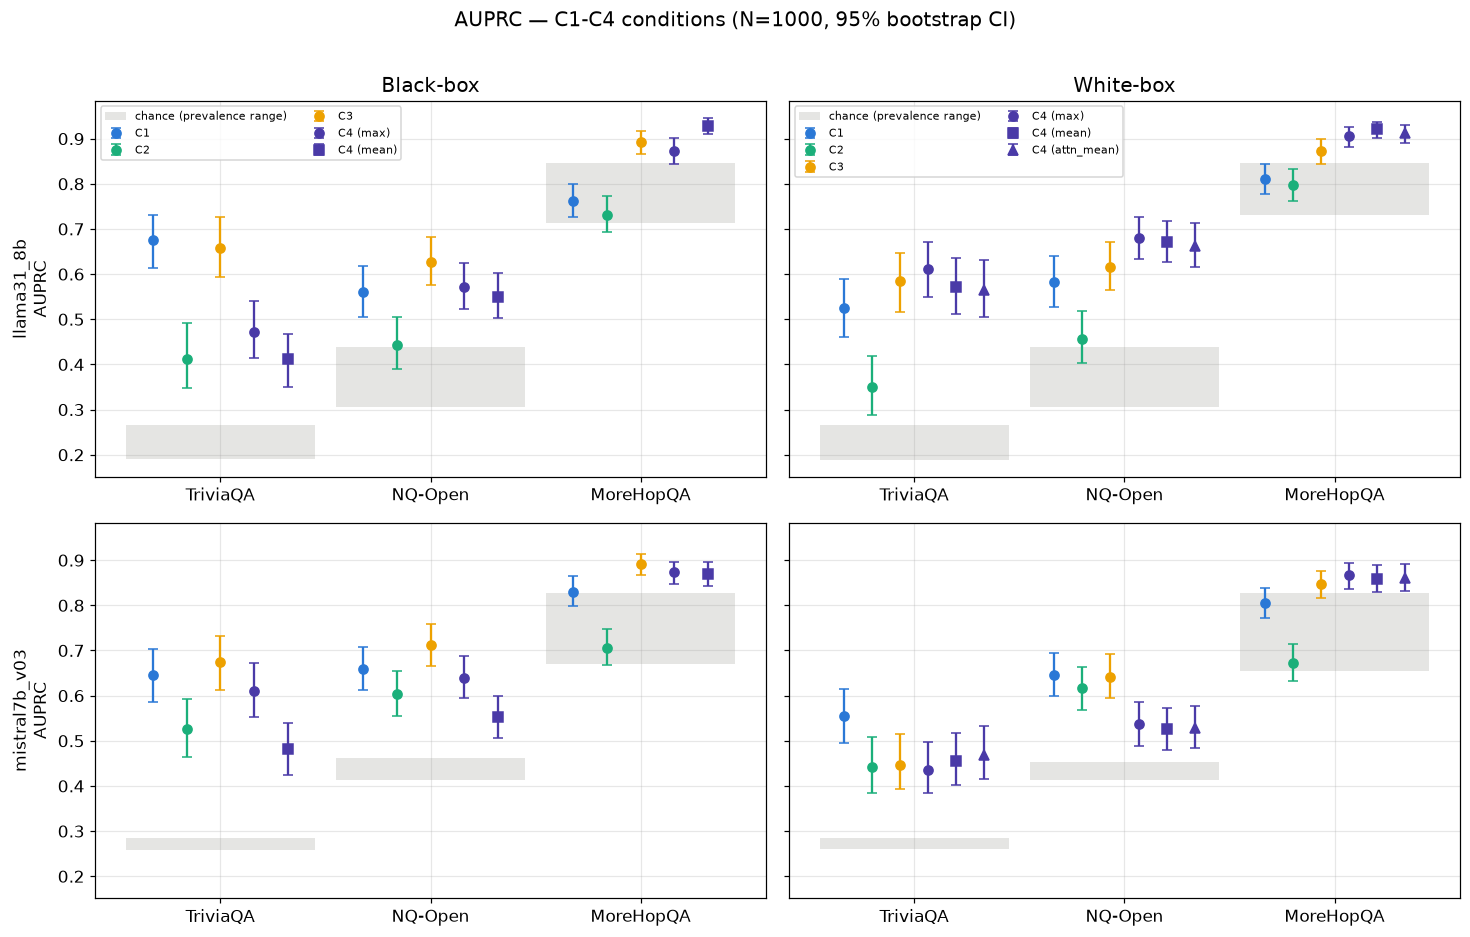

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auprc_baselines.png


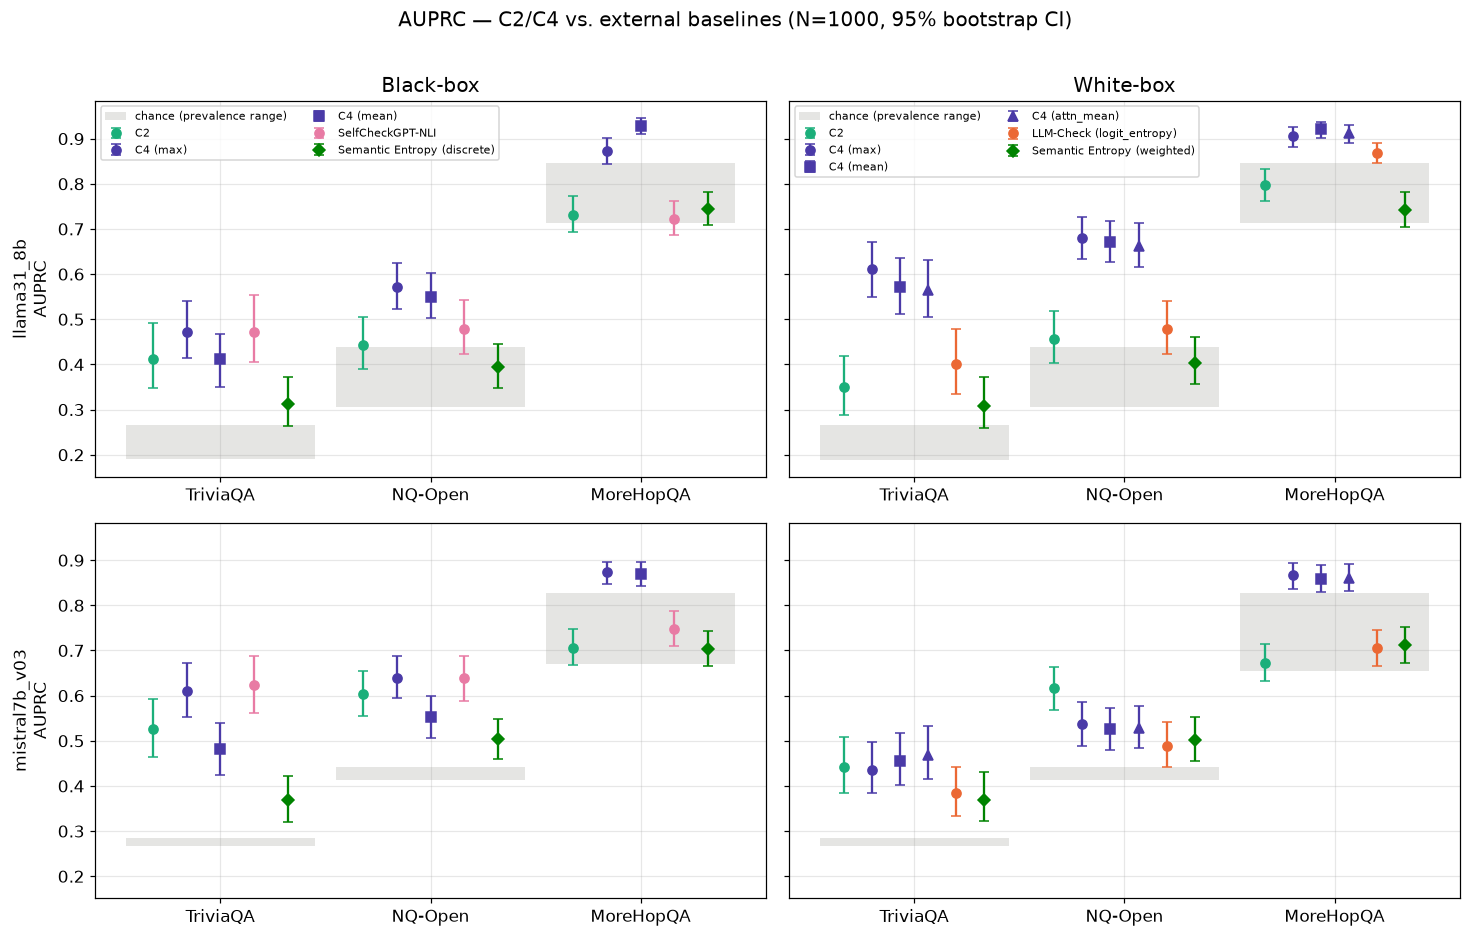

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/prr_by_condition.png


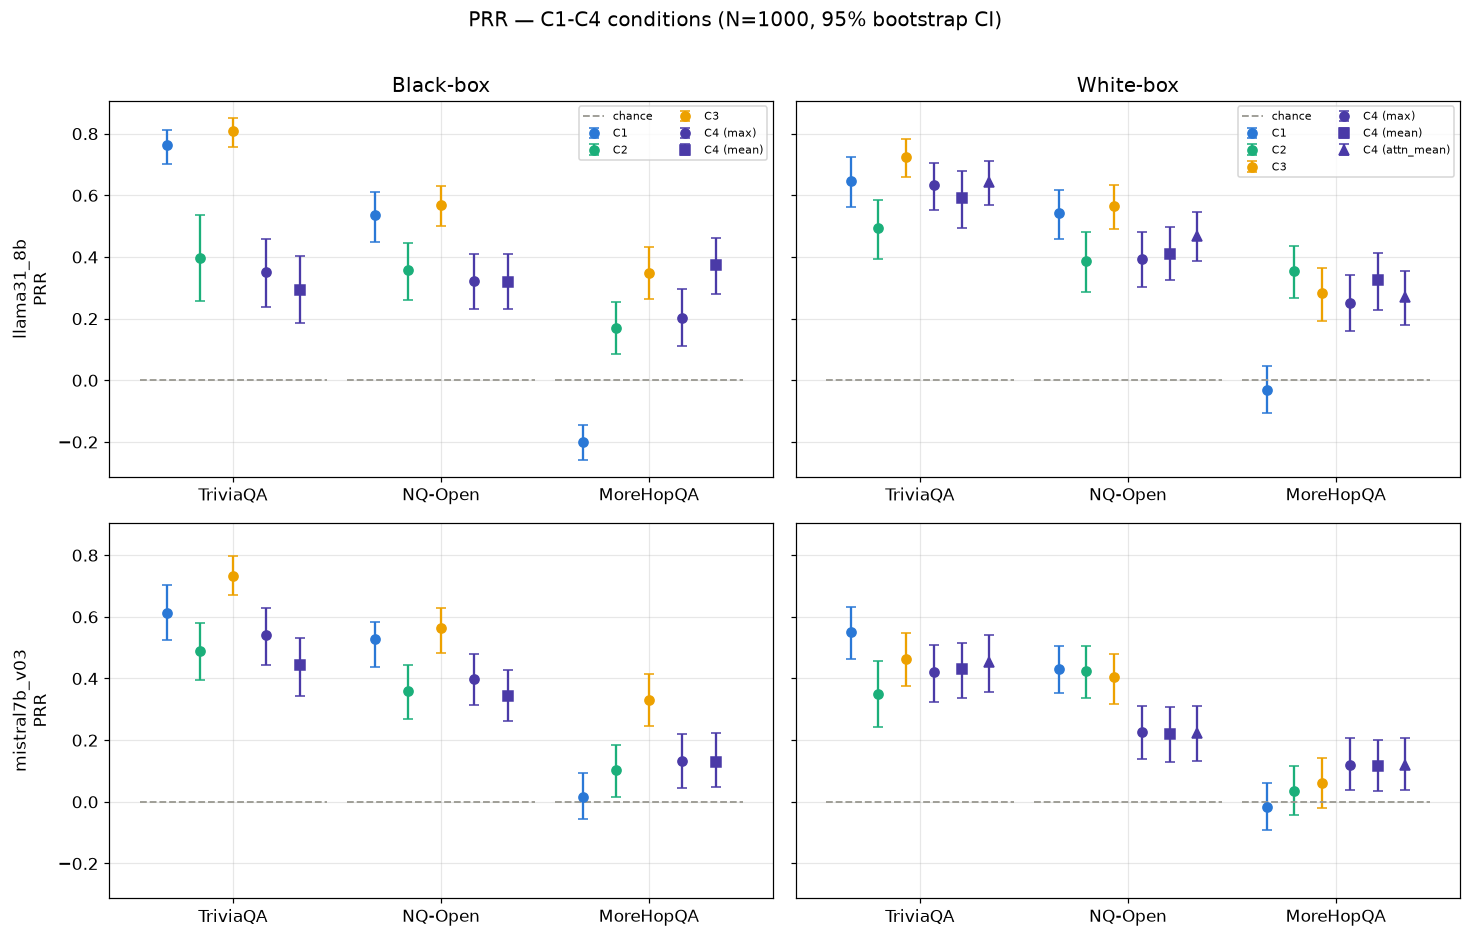

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/prr_baselines.png


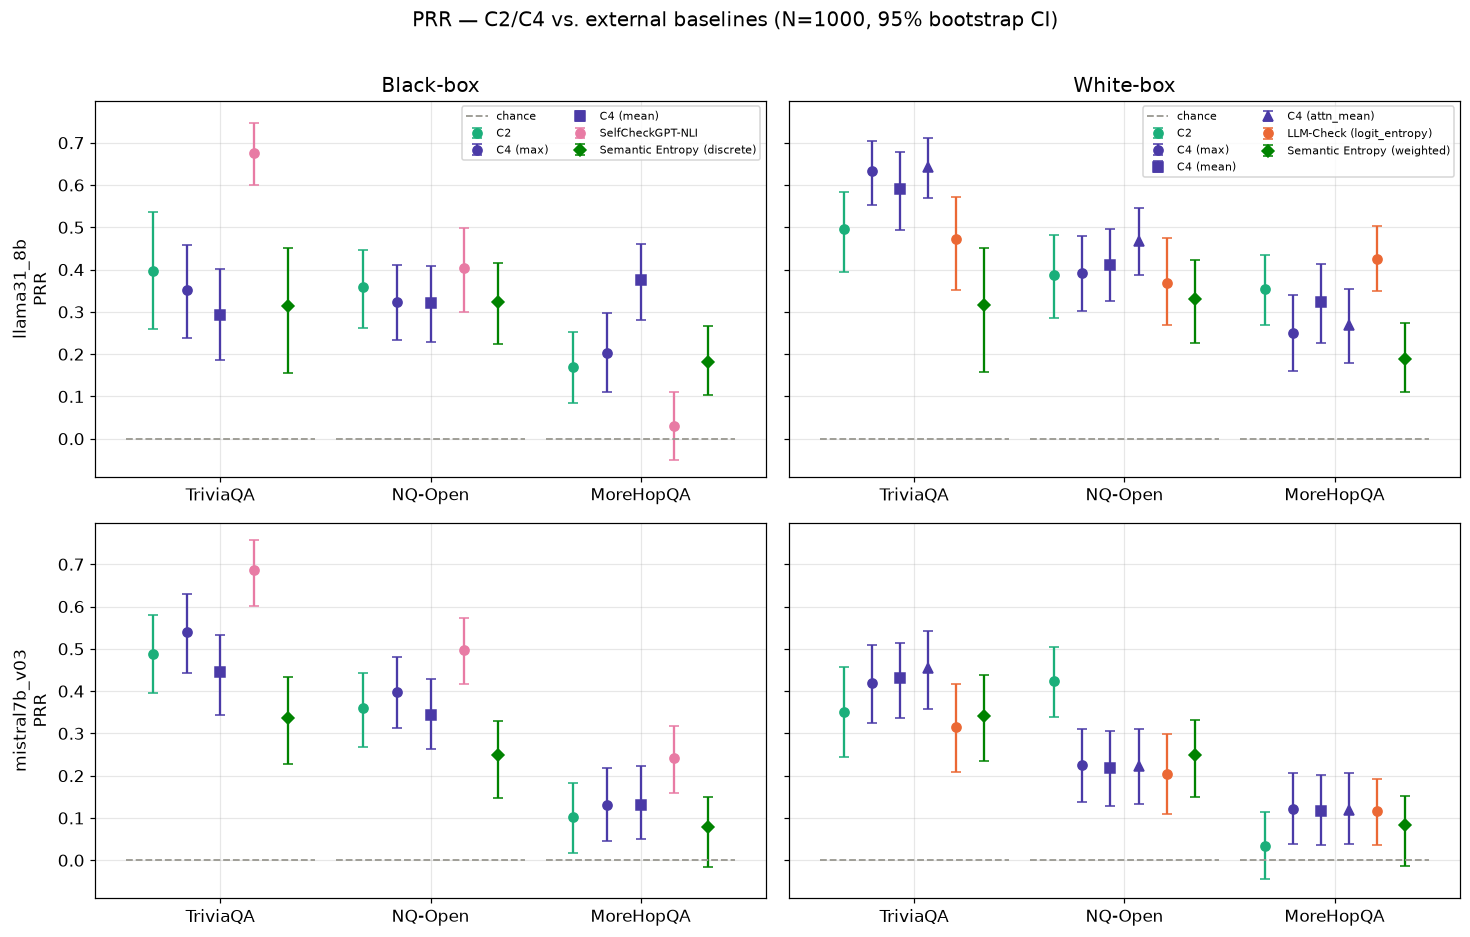

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fpr95_by_condition.png


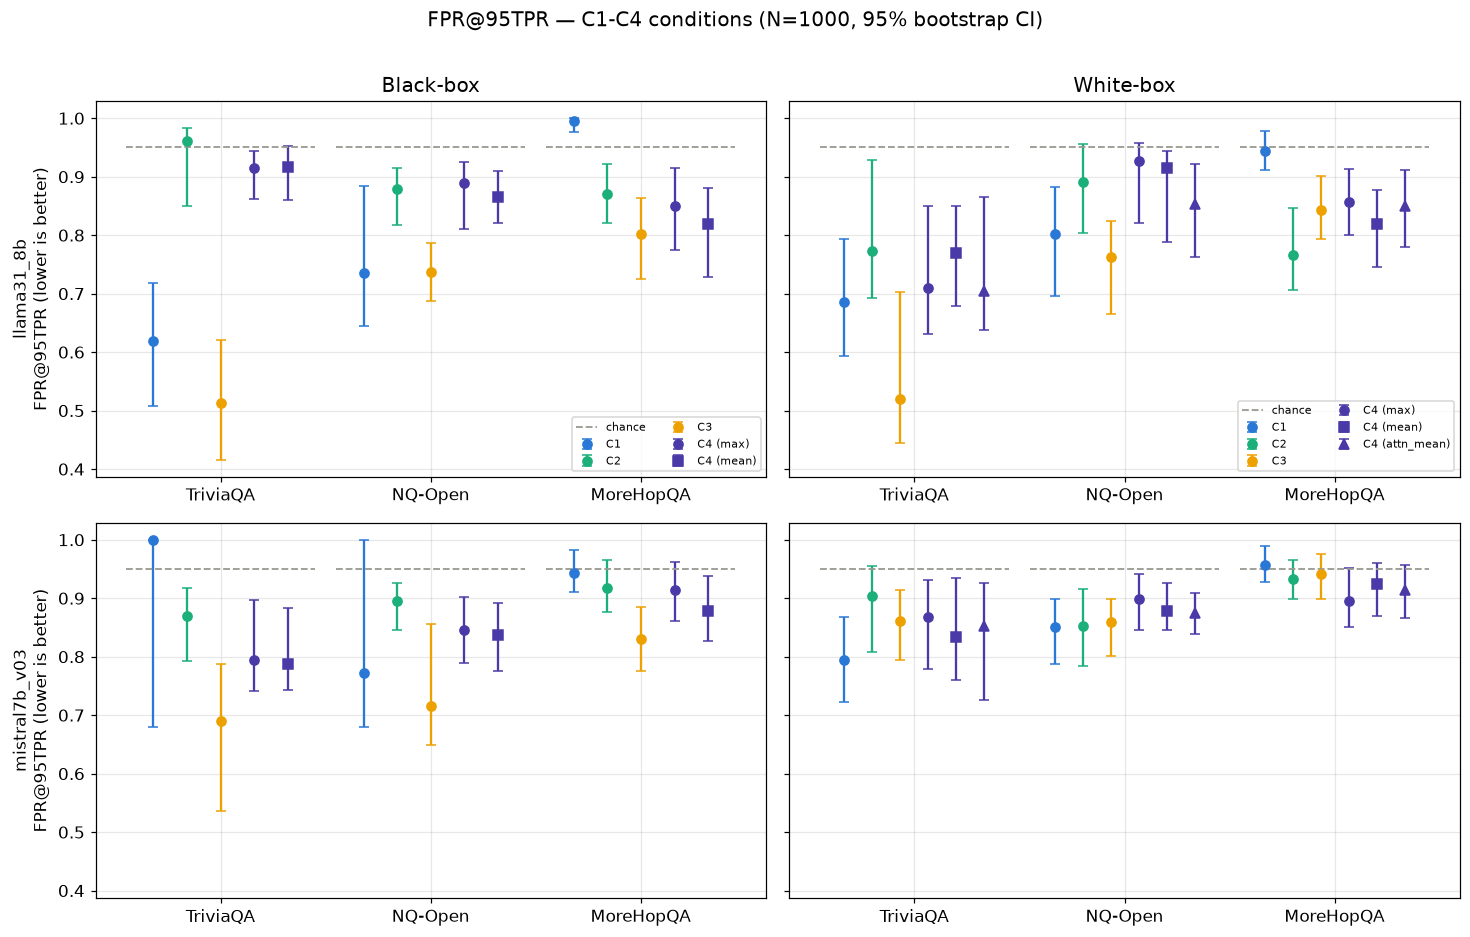

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fpr95_baselines.png


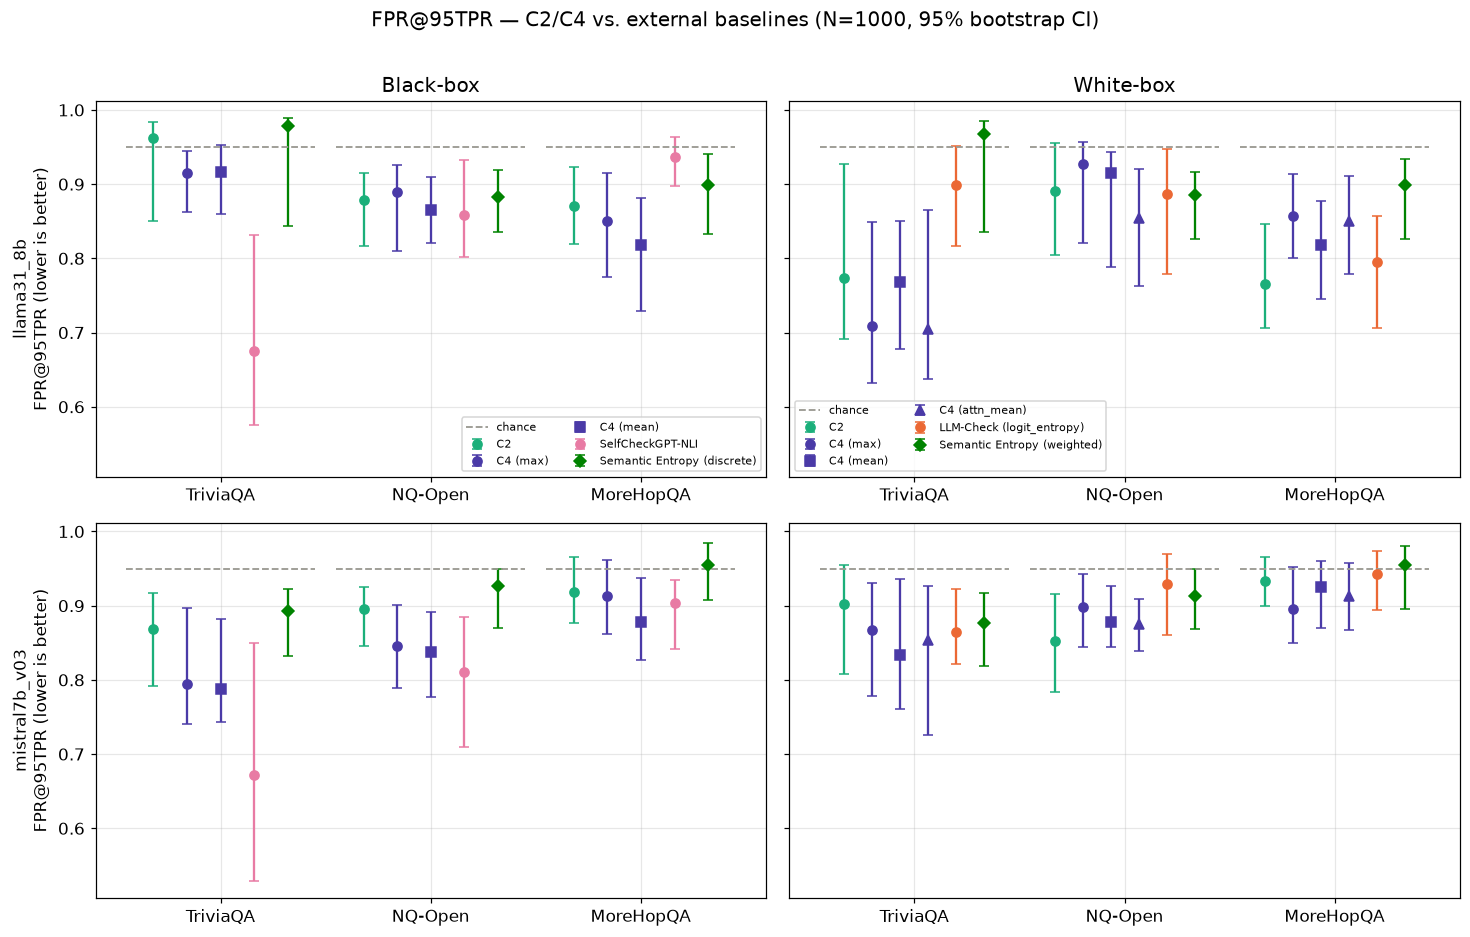

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auarc_by_condition.png


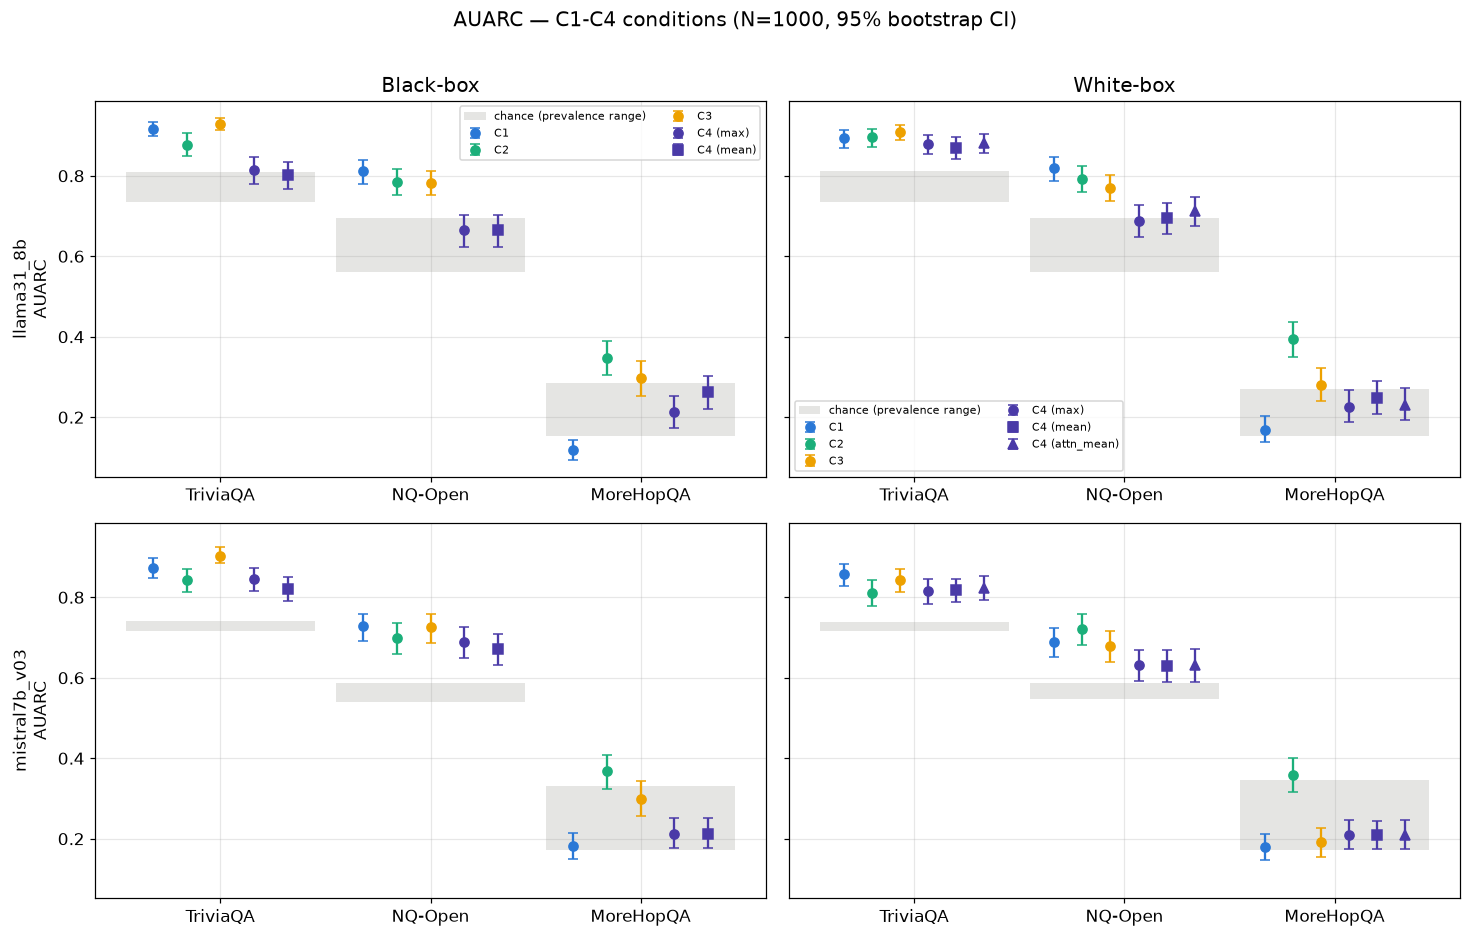

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/auarc_baselines.png


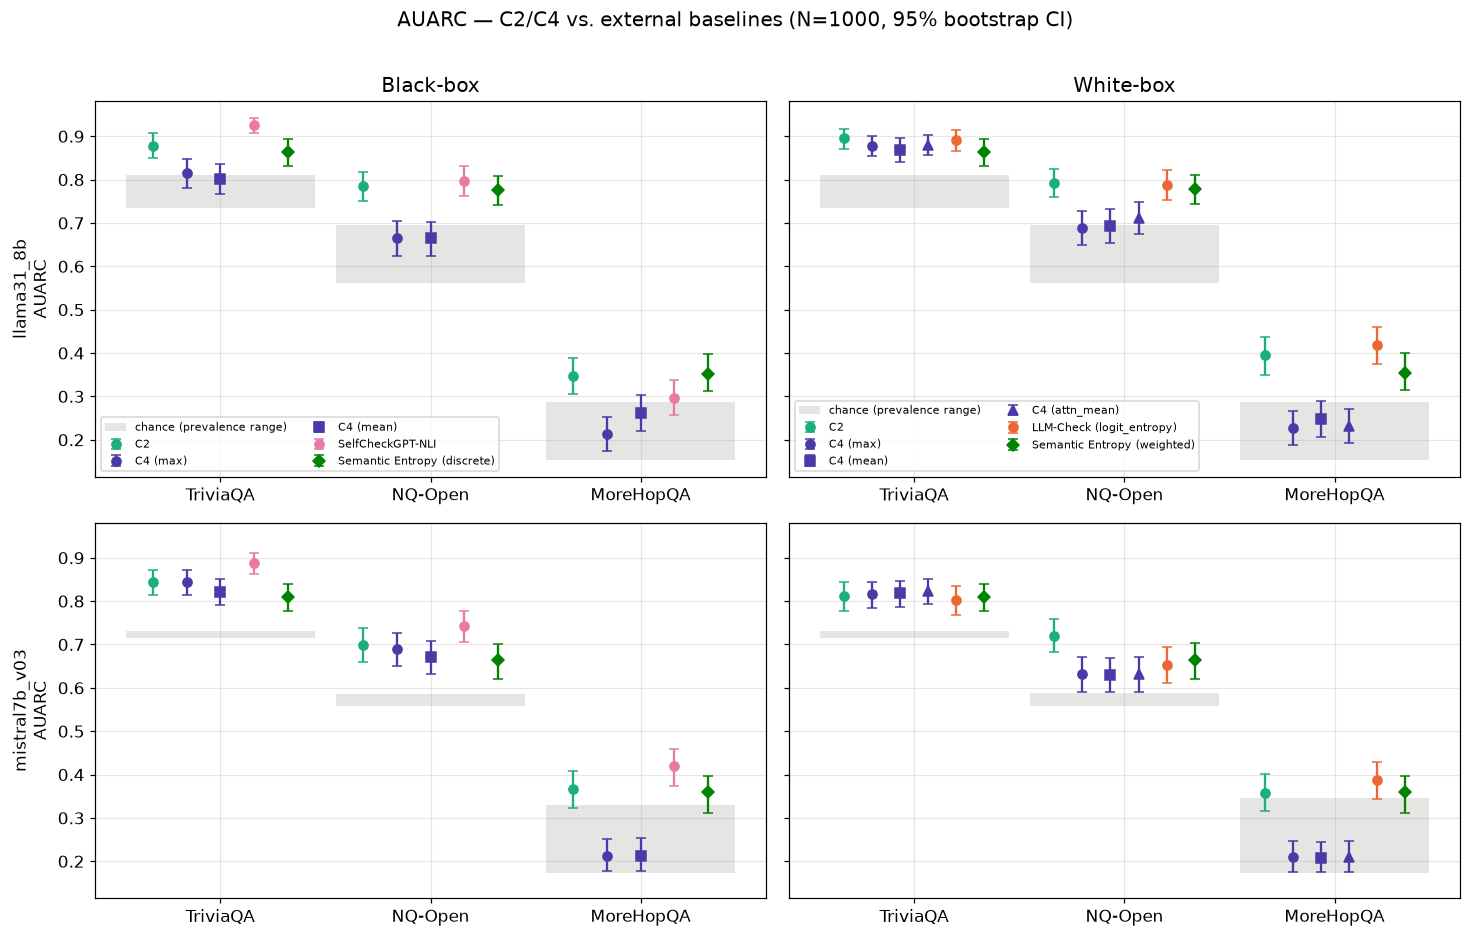

In [24]:
METRIC_SLUG = {"AUPRC": "auprc", "PRR": "prr", "FPR@95TPR": "fpr95", "AUARC": "auarc"}

# Scope "conditions" = Section 1 series; scope "baselines" = Section 3 series
# minus C3, i.e. C2 and C4 head-to-head with the external detectors.
METRIC_BARS = {
    "conditions": BARS,
    "baselines": {signal: [b for b in BASELINE_BARS[signal] if b[0] != "C3"] for signal in SIGNALS},
}
SCOPE_TITLE = {"conditions": "C1-C4 conditions", "baselines": "C2/C4 vs. external baselines"}
SCOPE_SUFFIX = {"conditions": "by_condition", "baselines": "baselines"}
METRIC_MARKER = {**MARKER, **BASELINE_MARKER}

def plot_metric(metric, scope):
    """Dot-and-whisker grid for one metric: rows = model, cols = access method."""
    higher_better = EXTRA_METRICS[metric][1]
    fig, axes = plt.subplots(len(MODEL_TAGS), len(SIGNALS), figsize=(13.5, 8.4), sharey=True)

    for i, model_tag in enumerate(MODEL_TAGS):
        model_label = MODEL_LABELS[model_tag]
        for j, signal in enumerate(SIGNALS):
            ax = axes[i, j]
            series = METRIC_BARS[scope][signal]
            k = len(series)
            w = 0.8 / k
            for m, (key, label, _) in enumerate(series):
                xs = [d + (m - (k - 1) / 2) * w for d in range(len(DATASETS))]
                vals = [EXTRA[(model_label, ds, signal, key, metric)] for ds in DATASETS]
                ys = [v[0] for v in vals]
                yerr = [[v[0] - v[1] for v in vals], [v[2] - v[0] for v in vals]]
                ax.errorbar(xs, ys, yerr=yerr, fmt=METRIC_MARKER[key], ms=6, capsize=3,
                            lw=1.5, ls="none", color=bar_color(key), label=label)

            # Chance: a line where it is constant across the group, a band where the
            # series have different prevalences (AUPRC / AUARC).
            for d, ds in enumerate(DATASETS):
                levels = [CHANCE_LEVEL[(model_label, ds, signal, key, metric)] for key, _, _ in series]
                lo_c, hi_c = min(levels), max(levels)
                first = (d == 0)
                if hi_c - lo_c > 0.01:
                    ax.fill_between([d - 0.45, d + 0.45], lo_c, hi_c, color=CHANCE_COLOR,
                                    alpha=0.25, lw=0, label="chance (prevalence range)" if first else None)
                else:
                    ax.plot([d - 0.45, d + 0.45], [lo_c, lo_c], ls="--", lw=1.2,
                            color=CHANCE_COLOR, label="chance" if first else None)

            ax.set_xticks(range(len(DATASETS)))
            ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
            if i == 0:
                ax.set_title(SIGNAL_LABELS[signal])
                ax.legend(fontsize=7, ncol=2, loc="best")  # series are identical down a column
            if j == 0:
                ax.set_ylabel(f"{model_label}\n{metric}" + ("" if higher_better else " (lower is better)"))

    fig.suptitle(f"{metric} — {SCOPE_TITLE[scope]} (N=1000, 95% bootstrap CI)", y=1.01)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, f"{METRIC_SLUG[metric]}_{SCOPE_SUFFIX[scope]}.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


for metric in EXTRA_METRICS:
    for scope in ("conditions", "baselines"):
        plot_metric(metric, scope)

**Notes — Section 5 figures**

- **AUPRC** rewards precision at the top of the ranking, so read it against the prevalence band in the same panel: on MoreHopQA the band sits at 0.7–0.85, which makes even a high raw AUPRC there a weak result, while on TriviaQA (band ≈0.19–0.29) the same number is a strong one.
- **PRR** is the one metric in this set that is directly comparable across every panel, because its normalization absorbs the different base accuracies. Where a PRR CI includes 0, the score is no better than rejecting answers at random — the practical restatement of an AUROC near chance.
- **FPR@95TPR** is the deployment view: how many correct answers you throw away to catch 95% of the hallucinations. Values close to the 0.95 line mean the detector buys essentially nothing at that operating point, even when its AUROC looks respectable — a gap worth pointing out explicitly in the thesis text.
- **AUARC** is included for completeness (PRR is its normalized form). It tracks the base accuracy of the cell more than the quality of the score, so never compare it across datasets; the C1 MoreHopQA panels are the clearest illustration.
- Intervals are unpaired per-run bootstraps, as in Sections 2–3: overlapping CIs are not a significance test for series that share generations (C2 vs. the baselines).

## 6. Token Cost — C1–C4, Generation vs. Forward-Pass

Compute cost per condition, counted in **tokens**, with the forward-pass component kept separate from generation. Accounting follows `results/kle_auroc_comparison.ipynb` (Charts 10/12):

- **Generated tokens** (`n_gen_tokens`) — autoregressive sampling: the 10 high-temperature samples plus the low-temperature candidate, and for C4 additionally every step continuation. This is the expensive kind.
- **Forward-pass tokens** (`n_fwd_tokens`) — teacher-forced re-encoding for hidden-state / attention extraction. White-box only; black-box runs have none by construction. Parallel over the sequence, so much cheaper *per token* than generation — the stacked bars are not a wall-clock ratio.
- **Prompt tokens** are reported in the table but excluded from the plotted total: they are small and the C4 logs do not record them, so including them would make conditions incomparable.
- **`t_seconds` is reported but never plotted.** C4 generates with batched `num_return_sequences` while C1–C3 loop sequentially, so wall-clock is not comparable across conditions — token counts are the fair cross-condition metric (cross-check against Slurm `sacct` is a separate step).

The C4 pipelines predate the `n_*` cost-key rename and store `gen_tokens` / `fwd_tokens`; both spellings are read below.

In [25]:
TOKEN_CONDS = ["C1", "C2", "C3", "C4:max"]     # C4 cost is identical across aggregations
TOKEN_COND_LABELS = {"C1": "C1", "C2": "C2", "C3": "C3", "C4:max": "C4"}


def token_costs(cond, signal, dataset, model_tag):
    """Per-question token counts for one run.

    Returns (gen, fwd, prompt, seconds) as arrays. The C4 pipelines wrote
    `gen_tokens` / `fwd_tokens` before the `n_*` rename, and record no prompt
    tokens at all -> NaN rather than a silent zero.
    """
    d = load_result(cond, signal, dataset, model_tag)
    det = [r for r in d["details"] if r.get("error") is None]

    def col(key, legacy, default=0.0):
        return np.array([(r.get("cost") or {}).get(key, (r.get("cost") or {}).get(legacy, default))
                         for r in det], dtype=float)

    return (col("n_gen_tokens", "gen_tokens"), col("n_fwd_tokens", "fwd_tokens"),
            col("n_prompt_tokens", "prompt_tokens", np.nan), col("t_seconds", "t_seconds", np.nan))


# TOK[(model_label, dataset, signal, cond_key)] = (mean_gen, mean_fwd)
TOK = {}
rows = []
for model_tag in MODEL_TAGS:
    for dataset in DATASETS:
        for signal in SIGNALS:
            for key in TOKEN_CONDS:
                cond = key.split(":")[0].lower()
                gen, fwd, prompt, secs = token_costs(cond, signal, dataset, model_tag)
                total = gen + fwd
                TOK[(MODEL_LABELS[model_tag], dataset, signal, key)] = (gen.mean(), fwd.mean())
                rows.append({
                    "model": MODEL_LABELS[model_tag],
                    "dataset": dataset,
                    "signal": signal,
                    "condition": TOKEN_COND_LABELS[key],
                    "n_questions": len(gen),
                    "mean_gen_tokens": gen.mean(),
                    "median_gen_tokens": float(np.median(gen)),
                    "sd_gen_tokens": float(gen.std(ddof=1)),
                    "mean_fwd_tokens": fwd.mean(),
                    "median_fwd_tokens": float(np.median(fwd)),
                    "mean_total_tokens": total.mean(),
                    "fwd_share_of_total": float(fwd.sum() / total.sum()) if total.sum() else 0.0,
                    "mean_prompt_tokens": float(np.nanmean(prompt)) if not np.isnan(prompt).all() else np.nan,
                    # wall-clock is NOT comparable across conditions (C4 batches its
                    # samples, C1-C3 loop) - reported for the record only
                    "mean_t_seconds": float(np.nanmean(secs)) if not np.isnan(secs).all() else np.nan,
                    "auroc": lookup_auroc(df_auroc, MODEL_LABELS[model_tag], dataset, signal, key),
                })

df_token_cost = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "token_cost.csv")
df_token_cost.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")
df_token_cost

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/token_cost.csv


,model,dataset,signal,condition,n_questions,mean_gen_tokens,median_gen_tokens,sd_gen_tokens,mean_fwd_tokens,median_fwd_tokens,mean_total_tokens,fwd_share_of_total,mean_prompt_tokens,mean_t_seconds,auroc
0,llama31_8b,triviaqa,blackbox,C1,1000,274.877,258.5,103.476361,0.000,0.0,274.877,0.000000,66.382,9.372017,0.843151
1,llama31_8b,triviaqa,blackbox,C2,1000,1205.376,1190.5,229.853007,0.000,0.0,1205.376,0.000000,90.473,35.523283,0.709474
2,llama31_8b,triviaqa,blackbox,C3,1000,1060.712,1026.5,252.227052,0.000,0.0,1060.712,0.000000,102.473,29.020841,0.864022
3,llama31_8b,triviaqa,blackbox,C4,1000,2069.034,2060.0,252.454741,0.000,0.0,2069.034,0.000000,NaN,15.656886,0.677258
4,llama31_8b,triviaqa,whitebox,C1,1000,263.261,251.0,100.714976,917.081,898.0,1180.342,0.776962,66.382,1.704825,0.781801
5,llama31_8b,triviaqa,whitebox,C2,1000,1192.887,1182.0,232.592634,2087.617,2063.0,3280.504,0.636371,90.473,6.697930,0.691712
6,llama31_8b,triviaqa,whitebox,C3,1000,1048.391,1008.5,258.237985,2063.121,2016.0,3111.512,0.663061,102.473,6.770959,0.820879
7,llama31_8b,triviaqa,whitebox,C4,1000,2069.034,2060.0,252.454741,6023.064,5934.0,8092.098,0.744314,NaN,8.890050,0.784557
8,llama31_8b,nqopen,blackbox,C1,1000,365.854,364.5,123.644129,0.000,0.0,365.854,0.000000,58.308,8.341889,0.727875
9,llama31_8b,nqopen,blackbox,C2,1000,1342.048,1320.5,257.688271,0.000,0.0,1342.048,0.000000,83.305,27.997107,0.644902


### Figure — AUROC against decomposed token cost

Layout follows Chart 12 of `results/kle_auroc_comparison.ipynb`, one figure per model: columns = dataset, top row = AUROC (C4 = the `max` aggregation used as primary throughout this notebook), bottom row = mean tokens per question with the bar **stacked** into generation (solid) and forward-pass (hatched, white-box only). Columns share the x-axis, so each condition can be read vertically as "what it detects" over "what it costs".

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/token_cost_stacked_8b.png


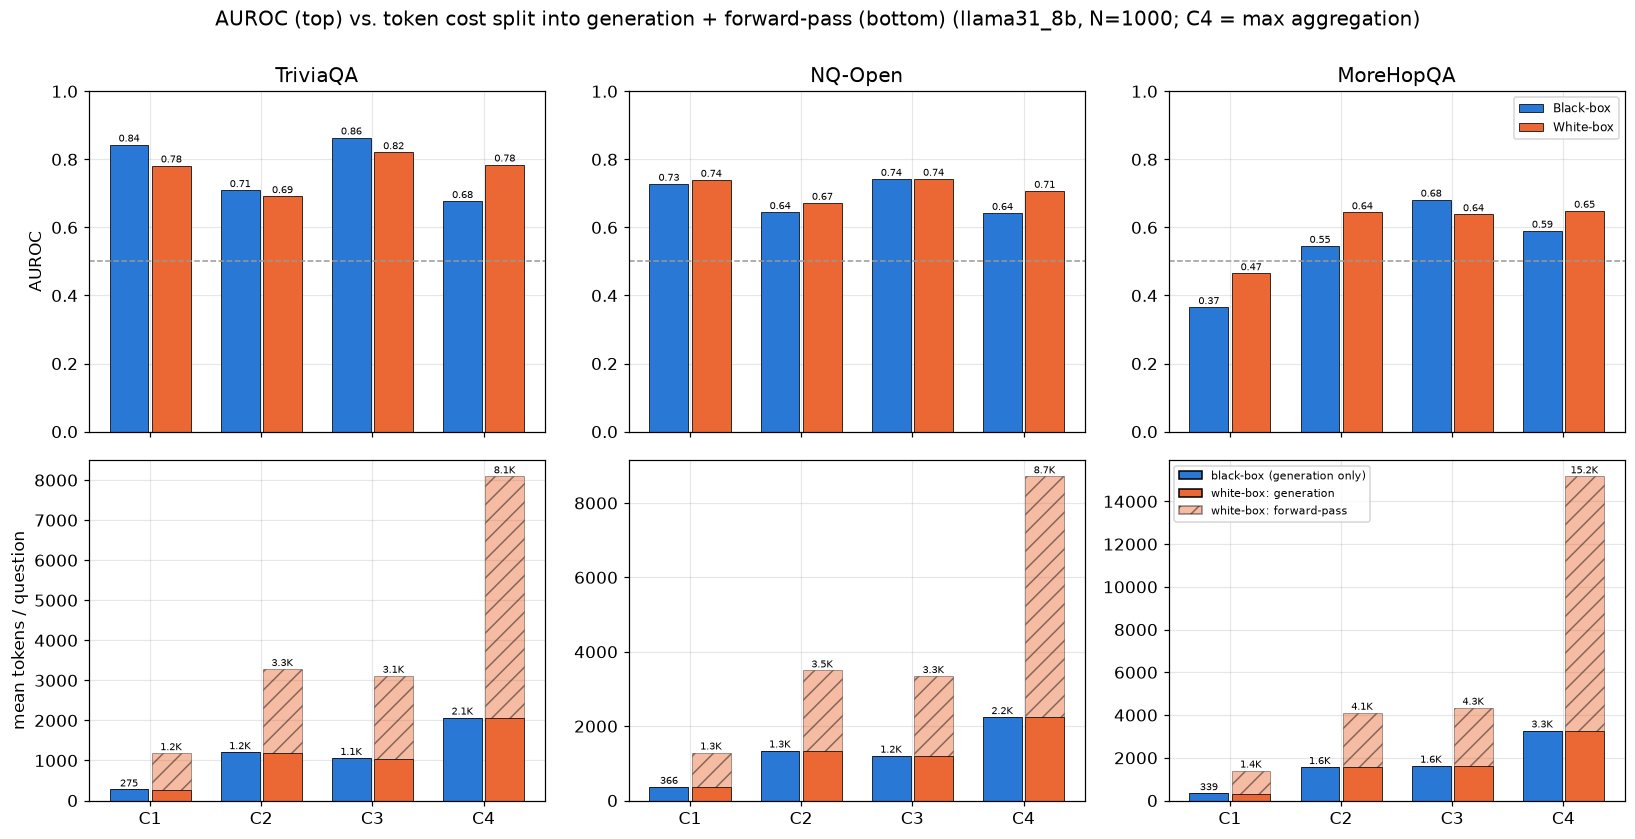

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/token_cost_stacked_mistral.png


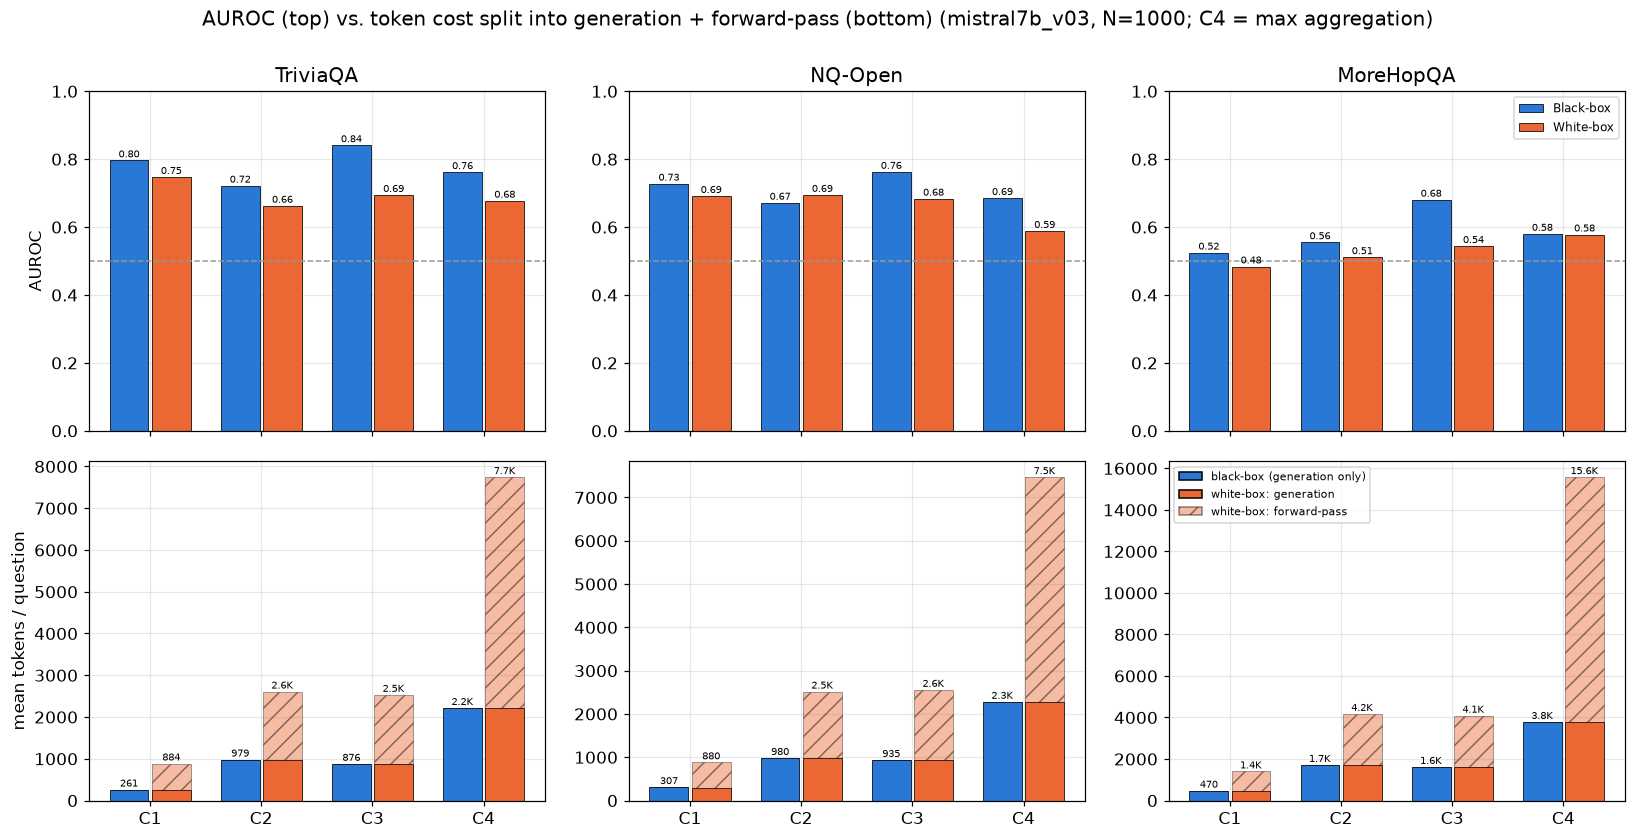

In [26]:
from matplotlib.patches import Patch

TOKEN_SIGNAL_COLORS = {"blackbox": "#2a78d6", "whitebox": "#eb6834"}


def fmt_tok(v):
    return f"{v / 1000:.1f}K" if v >= 1000 else f"{v:.0f}"


def plot_token_cost(model_tag, model_label):
    fig, axes = plt.subplots(2, len(DATASETS), figsize=(15, 7.6), sharex="col")
    for col, dataset in enumerate(DATASETS):
        ax_a, ax_t = axes[0][col], axes[1][col]
        w = 0.38
        for j, signal in enumerate(SIGNALS):
            xs = [i + (j - 0.5) * w for i in range(len(TOKEN_CONDS))]
            au = [lookup_auroc(df_auroc, model_label, dataset, signal, k) for k in TOKEN_CONDS]
            gen = [TOK[(model_label, dataset, signal, k)][0] for k in TOKEN_CONDS]
            fwd = [TOK[(model_label, dataset, signal, k)][1] for k in TOKEN_CONDS]
            ax_a.bar(xs, au, width=w * 0.92, color=TOKEN_SIGNAL_COLORS[signal],
                     edgecolor="black", linewidth=0.5, label=SIGNAL_LABELS[signal])
            ax_t.bar(xs, gen, width=w * 0.92, color=TOKEN_SIGNAL_COLORS[signal],
                     edgecolor="black", linewidth=0.5)
            ax_t.bar(xs, fwd, width=w * 0.92, bottom=gen, color=TOKEN_SIGNAL_COLORS[signal],
                     alpha=0.45, hatch="//", edgecolor="black", linewidth=0.5)
            for x, v in zip(xs, au):
                ax_a.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                              xytext=(0, 2), ha="center", fontsize=6.5)
            for x, g, f in zip(xs, gen, fwd):
                ax_t.annotate(fmt_tok(g + f), (x, g + f), textcoords="offset points",
                              xytext=(0, 2), ha="center", fontsize=6.5)
        ax_a.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1)
        ax_a.set_ylim(0, 1.0)
        ax_a.set_title(DATASET_LABELS[dataset])
        ax_t.set_xticks(range(len(TOKEN_CONDS)))
        ax_t.set_xticklabels([TOKEN_COND_LABELS[k] for k in TOKEN_CONDS])

    axes[0][0].set_ylabel("AUROC")
    axes[1][0].set_ylabel("mean tokens / question")
    axes[0][-1].legend(loc="upper right", fontsize=8)
    axes[1][-1].legend(handles=[
        Patch(facecolor=TOKEN_SIGNAL_COLORS["blackbox"], edgecolor="black",
              label="black-box (generation only)"),
        Patch(facecolor=TOKEN_SIGNAL_COLORS["whitebox"], edgecolor="black",
              label="white-box: generation"),
        Patch(facecolor=TOKEN_SIGNAL_COLORS["whitebox"], edgecolor="black", alpha=0.45,
              hatch="//", label="white-box: forward-pass"),
    ], loc="upper left", fontsize=7.5)
    fig.suptitle(f"AUROC (top) vs. token cost split into generation + forward-pass (bottom) "
                 f"({model_label}, N=1000; C4 = max aggregation)", y=1.0)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, f"token_cost_stacked_{model_tag}.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


for model_tag in MODEL_TAGS:
    plot_token_cost(model_tag, MODEL_LABELS[model_tag])

**Notes — Section 6**

- **Cost ladder: C1 << C2 ≈ C3 << C4.** The CoT conditions pay several times the direct-answer baseline in generated tokens, and C4's step continuations put it clearly on top; on MoreHopQA everything roughly doubles again (longer chains, `max_steps=5`), so cost scales with hop count.
- **C3 costs about what C2 costs** — answer-span extraction reuses the same chains — while detecting consistently better. There is no cost argument for preferring C2 anywhere in the matrix.
- **The black-box/white-box difference is almost entirely forward-pass load:** generation counts are near-identical per condition (the white-box runs decode the same chains), and the surplus is teacher-forced re-encoding, largest for C4 where every step is re-encoded. Read the hatched segment as parallel compute, not as wall-clock — a bar that is 4× taller is nowhere near 4× slower.
- Pair this with the AUROC row above it: on single-hop, C1 buys most of the detection quality for a fraction of the tokens, while on MoreHopQA the cheap condition is *below chance* and the expensive stepwise one is the only black-box method that works — the compute-side complement of the RQ1 story.
- `mean_t_seconds` is in the CSV for completeness only. C4 batches its samples via `num_return_sequences` while C1–C3 loop sequentially, so seconds compare pipelines, not methods.

## 7. Paired Bootstrap Comparisons

Sections 2–5 report per-run intervals: each series is bootstrapped on its own, so two overlapping CIs say nothing precise about the *difference* between them. This section closes that gap. Nothing is generated here either — everything is recomputed post-hoc from the per-question scores and labels already stored under `results/`.

**Procedure.** For a comparison of series A against B:

1. Restrict to the question ids present in **both** runs (reported as `n_paired`).
2. For each of B=2000 bootstrap iterations, draw one resample of question ids with replacement and recompute the metric for **A and B on that same resample**. This shared draw is what makes the comparison paired: the sampling noise common to both series cancels out of the difference.
3. Collect Δ = metric(A) − metric(B) and report the point estimate, the 95% percentile interval, and a two-sided p-value `p = 2 · min(P(Δ ≤ 0), P(Δ ≥ 0))`, clipped to 1.0.

`bootstrap_seed = 0` and `n_boot = 2000` as everywhere else in this notebook.

**Why pairing happens on ids, not on labels.** C1–C4 each run their own generation, so the same question can be answered correctly under one condition and hallucinated under another: the *labels differ between conditions by design*. Pairing is therefore done at the question-id level and **each series keeps its own labels** — a paired comparison of two detectors operating on two different answer distributions, which is exactly the quantity of interest for RQ1. Each row carries both hallucination rates (`halluc_rate_a`, `halluc_rate_b`) so this difference in operating regime stays visible.

**Which rows are strictly like-for-like** is recorded in the `same_generations` column, and verified by assertion wherever it is `True`:

- C4 aggregation pairs (`max` vs. `mean` / `attn_mean`) read one and the same run → identical labels.
- A baseline against the C2 run it was derived from: SelfCheckGPT-NLI and Semantic Entropy are computed from the **black-box** C2 logs, LLM-Check from the **white-box** C2 log (verified: label agreement exactly 1.000 in all six cells).
- Everything else is `False`, including two cases that are easy to misread. The **black-box and white-box C2 runs generate independently** — their labels agree on only 76–92% of questions, unlike C4 where the reference chain is decoded deterministically and both boxes share it. So (i) every cross-signal row compares two different answer distributions, and (ii) Semantic Entropy `se_weighted` appears in the white-box panel because it needs likelihoods, but it scores the *black-box* C2 generations, so its comparison against white-box C2 is a detector comparison across two runs, not a same-generation ablation.

**Comparisons produced** (per model × dataset, and per signal unless stated):

- **Condition contrasts:** C3−C2, C4(max)−C2, C4(max)−C3, C2−C1, C3−C1.
- **C4 aggregation:** max−mean, and max−attn_mean in white-box.
- **Signal axis:** white-box − black-box for each of C1, C2, C3, C4(max) — same question ids, each side with its own labels.
- **External baselines:** each of C2, C3, C4(max) against Semantic Entropy (`se_discrete` in black-box, `se_weighted` in white-box), against SelfCheckGPT-NLI (black-box) and against LLM-Check `logit_entropy` (white-box).

The whole procedure is run twice: once for **AUROC** and once for **PRR**, the latter because it is the only metric in this notebook that is comparable across cells with different base accuracies.

In [27]:
def baseline_records(method, variant, dataset, model_tag):
    """(ids, scores, labels) for one baseline cell.

    Same files as `baseline_scores` in Section 3, but the question ids are kept:
    the paired bootstrap below needs them to align two runs question by question.
    """
    if method == "SelfCheckGPT-NLI":
        path = os.path.join(SELFCHECK_DIR, f"selfcheck_c2_{dataset}_{model_tag}_results.json")
        with open(path, encoding="utf-8") as f:
            det = [r for r in json.load(f)["details"] if r.get("error") is None]
        s = np.array([r["score"] for r in det], dtype=float)
    elif method == "LLM-Check":
        path = os.path.join(LLMCHECK_DIR, f"llmcheck_c2_{dataset}_{model_tag}_results.json")
        with open(path, encoding="utf-8") as f:
            det = [r for r in json.load(f)["details"] if r.get("error") is None]
        s = np.array([r["scores"][variant] for r in det], dtype=float)
    elif method == "SemanticEntropy":
        with open(SE_FILE, encoding="utf-8") as f:
            det = json.load(f)["cells"][f"c2_{dataset}_{model_tag}"]["details"]
        s = np.array([r[variant] for r in det], dtype=float)
    else:
        raise ValueError(f"Unknown baseline method: {method}")
    ids = [r["id"] for r in det]
    y = np.array([int(r["is_halluc"]) for r in det], dtype=int)
    return ids, s, y


def series_records(model_tag, dataset, signal, key):
    """(ids, scores, labels) for any series key used in this notebook.

    C1-C3 store the frozen-dataset id under "id", C4 under "qid"; the baselines
    use "id". Orientation is uniform: higher score = more likely hallucination.
    """
    head, _, tail = key.partition(":")
    if head not in CONDITION_LABELS.values():
        return baseline_records(head, tail or None, dataset, model_tag)

    cond = head.lower()
    d = load_result(cond, signal, dataset, model_tag)
    if cond == "c4":
        det = [r for r in d["details"] if r.get("error") is None and r.get("agg")]
        ids = [r["qid"] for r in det]
        s = np.array([r["agg"][tail] for r in det], dtype=float)
        y = np.array([int(r["is_halluc"]) for r in det], dtype=int)
    else:
        score_key = "kle_full" if signal == "blackbox" else "vne"
        det = d["details"]
        ids = [r["id"] for r in det]
        s = np.array([r[score_key] for r in det], dtype=float)
        y = np.array([0 if r["judge_correct"] else 1 for r in det], dtype=int)
    return ids, s, y


def paired_delta(rec_a, rec_b, metric_fn, assert_same_labels=False,
                 n_boot=N_BOOT, seed=BOOTSTRAP_SEED):
    """Paired bootstrap of metric(A) - metric(B) over shared question ids.

    Each iteration draws ONE resample of question ids and scores both series on
    it, so the noise the two share cancels in the difference. Every condition
    carries its own labels (C1-C4 generate their own answers, so the same
    question can be correct under one condition and hallucinated under another);
    `assert_same_labels` is for the C2-vs-baseline pairs, where the baselines
    score the identical C2 generations and the labels must match exactly.
    """
    ids_a, s_a, y_a = rec_a
    ids_b, s_b, y_b = rec_b
    pos_b = {qid: i for i, qid in enumerate(ids_b)}
    ia = np.array([i for i, qid in enumerate(ids_a) if qid in pos_b], dtype=int)
    ib = np.array([pos_b[ids_a[i]] for i in ia], dtype=int)
    sa, ya, sb, yb = s_a[ia], y_a[ia], s_b[ib], y_b[ib]
    n = len(ia)
    if assert_same_labels:
        assert np.array_equal(ya, yb), "paired series share generations but their labels differ"

    rng = np.random.default_rng(seed)
    deltas = np.full(n_boot, np.nan)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)                 # one draw, used for both series
        ya_b, yb_b = ya[idx], yb[idx]
        if 0 < ya_b.sum() < n and 0 < yb_b.sum() < n:
            deltas[b] = metric_fn(ya_b, sa[idx]) - metric_fn(yb_b, sb[idx])
    d = deltas[~np.isnan(deltas)]
    lo, hi = np.percentile(d, [2.5, 97.5])
    p = min(1.0, 2 * min(float((d <= 0).mean()), float((d >= 0).mean())))
    return {
        "value_a": metric_fn(ya, sa),
        "value_b": metric_fn(yb, sb),
        "delta": metric_fn(ya, sa) - metric_fn(yb, sb),
        "ci_lo": float(lo),
        "ci_hi": float(hi),
        "p_two_sided": p,
        "n_paired": int(n),
        "halluc_rate_a": float(ya.mean()),
        "halluc_rate_b": float(yb.mean()),
    }


# Which C2 run each baseline was computed from. SelfCheckGPT-NLI and Semantic
# Entropy read the black-box C2 logs, LLM-Check the white-box one; only against
# that run do they share generations (and therefore labels).
BASELINE_SOURCE_SIGNAL = {"SelfCheckGPT-NLI": "blackbox", "SemanticEntropy": "blackbox",
                          "LLM-Check": "whitebox"}

BASELINE_KEYS_BY_SIGNAL = {
    "blackbox": ["SemanticEntropy:se_discrete", "SelfCheckGPT-NLI"],
    "whitebox": ["SemanticEntropy:se_weighted", "LLM-Check:logit_entropy"],
}


def comparison_specs():
    """(signal_field, comparison_label, (signal_a, key_a), (signal_b, key_b))."""
    specs = []
    for signal in SIGNALS:
        pairs = [("C3", "C2"), ("C4:max", "C2"), ("C4:max", "C3"),
         ("C2", "C1"), ("C3", "C1"), ("C4:max", "C4:mean"),
         ("C4:mean", "C2")]
        if signal == "whitebox":
            pairs += [("C4:max", "C4:attn_mean"), ("C4:attn_mean", "C2")]
        for a in ("C2", "C3", "C4:max"):
            pairs += [(a, b) for b in BASELINE_KEYS_BY_SIGNAL[signal]]
        for a, b in pairs:
            specs.append((signal, f"{a} - {b}", (signal, a), (signal, b)))

    # Signal axis: same question ids, each side scored by its own pipeline.
    for cond in ("C1", "C2", "C3", "C4:max"):
        specs.append(("cross_signal", f"{cond} (whitebox) - {cond} (blackbox)",
                      ("whitebox", cond), ("blackbox", cond)))
    return specs


COMPARISONS = comparison_specs()
print(f"{len(COMPARISONS)} comparisons per model x dataset "
      f"-> {len(COMPARISONS) * len(MODEL_TAGS) * len(DATASETS)} rows per metric")

32 comparisons per model x dataset -> 192 rows per metric


In [28]:
def run_paired_comparisons(metric_fn, value_name):
    """Run every comparison for one metric and return the tidy table."""
    rows = []
    for model_tag in MODEL_TAGS:
        for dataset in DATASETS:
            cache = {}

            def rec(signal, key):
                if (signal, key) not in cache:
                    cache[(signal, key)] = series_records(model_tag, dataset, signal, key)
                return cache[(signal, key)]

            for signal_field, label, (sig_a, key_a), (sig_b, key_b) in COMPARISONS:
                head_a, head_b = key_a.partition(":")[0], key_b.partition(":")[0]
                # Rows that read one and the same generation run: the two series then
                # have identical labels question by question, which is asserted rather
                # than assumed. Two cases - C4 aggregation variants of one run, and a
                # baseline against the C2 run it was derived from (note that the
                # black-box and white-box C2 runs generate separately, so a baseline
                # only matches the box it was computed on).
                same_generations = bool(
                    (sig_a == sig_b and head_a == head_b)
                    or (key_a == "C2" and head_b in BASELINE_SOURCE_SIGNAL
                        and BASELINE_SOURCE_SIGNAL[head_b] == sig_a))
                out = paired_delta(rec(sig_a, key_a), rec(sig_b, key_b), metric_fn,
                                   assert_same_labels=same_generations)
                ma, _, va = key_a.partition(":")
                mb, _, vb = key_b.partition(":")
                rows.append({
                    "model": MODEL_LABELS[model_tag],
                    "dataset": dataset,
                    "signal": signal_field,
                    "comparison": label,
                    "method_a": ma, "variant_a": va or None,
                    "method_b": mb, "variant_b": vb or None,
                    f"{value_name}_a": out["value_a"],
                    f"{value_name}_b": out["value_b"],
                    "delta": out["delta"],
                    "ci_lo": out["ci_lo"],
                    "ci_hi": out["ci_hi"],
                    "p_two_sided": out["p_two_sided"],
                    "n_paired": out["n_paired"],
                    "same_generations": same_generations,
                    "halluc_rate_a": out["halluc_rate_a"],
                    "halluc_rate_b": out["halluc_rate_b"],
                    "n_boot": N_BOOT,
                    "bootstrap_seed": BOOTSTRAP_SEED,
                })
    return pd.DataFrame(rows)


t0 = time.time()
df_paired_auroc = run_paired_comparisons(fast_auroc, "auroc")
df_paired_prr = run_paired_comparisons(prr, "prr")
print(f"computed in {time.time() - t0:.0f}s")

for df, name in [(df_paired_auroc, "paired_delta_auroc.csv"), (df_paired_prr, "paired_delta_prr.csv")]:
    csv_path = os.path.join(TABLES_DIR, name)
    df.to_csv(csv_path, index=False, float_format="%.6f")
    print(f"{len(df)} rows -> {csv_path}")

# Significant AUROC differences, largest effect first (a quick read before the tables
# go into the thesis text).
sig = df_paired_auroc[df_paired_auroc["p_two_sided"] < 0.05]
print(f"\n{len(sig)} of {len(df_paired_auroc)} AUROC comparisons significant at p<0.05")
sig.reindex(sig["delta"].abs().sort_values(ascending=False).index)[
    ["model", "dataset", "signal", "comparison", "delta", "ci_lo", "ci_hi", "p_two_sided"]].head(15)

computed in 151s
192 rows -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/paired_delta_auroc.csv
192 rows -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/paired_delta_prr.csv

108 of 192 AUROC comparisons significant at p<0.05


,model,dataset,signal,comparison,delta,ci_lo,ci_hi,p_two_sided
68,llama31_8b,morehopqa,blackbox,C3 - C1,0.315770,0.254833,0.378071,0.0
105,mistral7b_v03,triviaqa,blackbox,C3 - SemanticEntropy:se_discrete,0.205968,0.159511,0.251043,0.0
9,llama31_8b,triviaqa,blackbox,C3 - SemanticEntropy:se_discrete,0.201228,0.152984,0.249465,0.0
2,llama31_8b,triviaqa,blackbox,C4:max - C3,-0.186764,-0.233890,-0.141303,0.0
74,llama31_8b,morehopqa,blackbox,C3 - SelfCheckGPT-NLI,0.180235,0.127517,0.234785,0.0
67,llama31_8b,morehopqa,blackbox,C2 - C1,0.179947,0.123792,0.240006,0.0
80,llama31_8b,morehopqa,whitebox,C2 - C1,0.179192,0.115713,0.243281,0.0
81,llama31_8b,morehopqa,whitebox,C3 - C1,0.173483,0.110553,0.236417,0.0
70,llama31_8b,morehopqa,blackbox,C4:mean - C2,0.167082,0.109035,0.219024,0.0
24,llama31_8b,triviaqa,whitebox,C3 - SemanticEntropy:se_weighted,0.161052,0.109043,0.210323,0.0


**Notes — Section 7**

- Read Δ as "A minus B in the same units as the metric": positive Δ means A is the better detector (for both AUROC and PRR, higher is better). The interval is the paired one, so it is generally *narrower* than the gap between the two unpaired intervals in Sections 2–5 — comparisons that look inconclusive there can be decisive here.
- `p_two_sided` is a bootstrap percentile p-value, not a t-test: it is the share of resamples on the wrong side of zero, doubled. With B=2000 it cannot resolve below ≈0.001, so p = 0.000 means "smaller than this bootstrap can measure", not zero.
- No multiple-comparison correction is applied. With ~29 comparisons per cell, treat isolated p-values just under 0.05 with the appropriate suspicion, and prefer effect sizes (Δ and its interval) over the significance flag when writing the results chapter.
- The condition contrasts confound two things on purpose: a different detector *and* a different answer distribution (each condition generates its own answers). That is the honest framing for RQ1 — "does switching to this condition give me a better detector overall" — and the two `halluc_rate_*` columns are there so the regime change is not lost.
- Rows with `same_generations = True` are the strictly like-for-like ones: identical generations, identical labels (asserted), only the scoring function differs. That covers the C4 aggregation pairs and each baseline against the C2 run it was derived from.
- **The black-box and white-box C2 runs are not the same run** — their labels agree on 76–92% of questions (lowest on MoreHopQA). Every cross-signal row therefore measures "black-box pipeline vs. white-box pipeline", not "same answers, two scores"; C4 is the exception where both boxes share a deterministically decoded chain.

### Figure — forest plot of the C4 − C2 contrasts

One panel per C4 aggregation, so "does stepwise scoring beat holistic CoT" can be read per aggregation strategy. Each row is one cell (model × access method × dataset); the dot is the paired Δ AUROC = C4(aggregation) − C2, the whisker its 95% paired bootstrap interval, and the dashed line marks Δ = 0. Filled markers are contrasts with p < 0.05, hollow ones are not distinguishable from zero; the p-value is printed at the right edge of each panel.

`attn_mean` exists only in white-box, so its panel leaves the black-box rows empty — row positions are shared across panels so the same cell sits on the same line everywhere. Values are read from `df_paired_auroc`, i.e. exactly the numbers in `paired_delta_auroc.csv`.

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/forest_c4_minus_c2_auroc.png


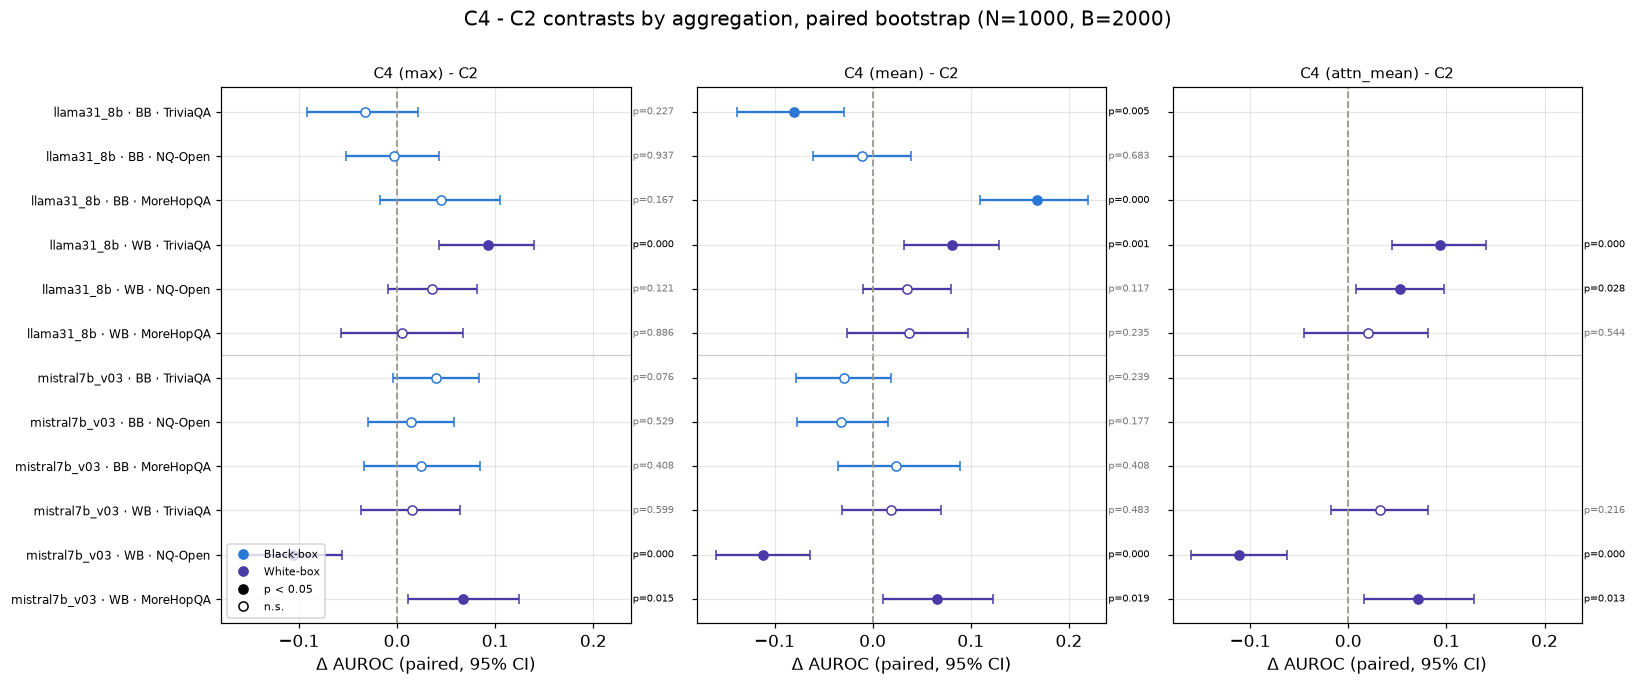

In [29]:
from matplotlib.lines import Line2D

FOREST_AGGS = [("max", "C4 (max) - C2"), ("mean", "C4 (mean) - C2"),
               ("attn_mean", "C4 (attn_mean) - C2")]
# Shared row order, so a cell keeps the same vertical position in every panel.
FOREST_ROWS = [(model_tag, signal, dataset)
               for model_tag in MODEL_TAGS for signal in SIGNALS for dataset in DATASETS]


def forest_lookup(agg, model_tag, signal, dataset):
    """The C4(agg) - C2 row of `df_paired_auroc`, or None if that cell has no such contrast."""
    sub = df_paired_auroc[(df_paired_auroc["model"] == MODEL_LABELS[model_tag])
                          & (df_paired_auroc["dataset"] == dataset)
                          & (df_paired_auroc["signal"] == signal)
                          & (df_paired_auroc["method_a"] == "C4")
                          & (df_paired_auroc["variant_a"] == agg)
                          & (df_paired_auroc["method_b"] == "C2")]
    return None if sub.empty else sub.iloc[0]


def plot_forest_c4_minus_c2():
    fig, axes = plt.subplots(1, len(FOREST_AGGS), figsize=(15, 6.2), sharex=True, sharey=True)
    for ax, (agg, title) in zip(axes, FOREST_AGGS):
        for i, (model_tag, signal, dataset) in enumerate(FOREST_ROWS):
            r = forest_lookup(agg, model_tag, signal, dataset)
            if r is None:
                continue
            significant = r["p_two_sided"] < 0.05
            ax.errorbar(r["delta"], i,
                        xerr=[[r["delta"] - r["ci_lo"]], [r["ci_hi"] - r["delta"]]],
                        fmt="o", ms=6, capsize=3, lw=1.5, color=SIGNAL_COLORS[signal],
                        markerfacecolor=SIGNAL_COLORS[signal] if significant else "white")
            ax.text(1.005, i, f"p={r['p_two_sided']:.3f}", transform=ax.get_yaxis_transform(),
                    va="center", fontsize=6.5, color="black" if significant else "#777777")
        ax.axvline(0, color=CHANCE_COLOR, ls="--", lw=1.2)
        ax.axhline(len(FOREST_ROWS) / 2 - 0.5, color="#cccccc", lw=0.8)   # model separator
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(r"$\Delta$ AUROC (paired, 95% CI)")

    axes[0].set_yticks(range(len(FOREST_ROWS)))
    axes[0].set_yticklabels(
        [f"{MODEL_LABELS[m]} · {'BB' if s == 'blackbox' else 'WB'} · {DATASET_LABELS[d]}"
         for m, s, d in FOREST_ROWS], fontsize=8)
    axes[0].invert_yaxis()
    handles = [Line2D([0], [0], marker="o", ls="none", color=SIGNAL_COLORS[s],
                      label=SIGNAL_LABELS[s]) for s in SIGNALS]
    handles += [Line2D([0], [0], marker="o", ls="none", color="black", markerfacecolor="black",
                       label="p < 0.05"),
                Line2D([0], [0], marker="o", ls="none", color="black", markerfacecolor="white",
                       label="n.s.")]
    axes[0].legend(handles=handles, fontsize=7.5, loc="lower left")
    fig.suptitle("C4 - C2 contrasts by aggregation, paired bootstrap (N=1000, B=2000)", y=1.0)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, "forest_c4_minus_c2_auroc.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


plot_forest_c4_minus_c2()

## 8. Hallucination Rate vs. Detection Quality

Every condition generates its own answers, so each cell has two independent properties: **how often the model hallucinates** (generation quality) and **how well the score separates those hallucinations from the correct answers** (detection quality). They are not the same axis and they do not have to move together — this section measures how they actually relate, for C1–C4 across all datasets, models and access methods.

Both quantities come from the runs already loaded above: the hallucination rate is the mean of the run's own labels, AUROC and its CI come from the Section 2 cache (C4 = `max`, the primary aggregation). No new computation beyond the correlations.

**Two levels of correlation, reported separately, because they point in different directions:**

- **Overall** (12 points per panel: 3 datasets × 4 conditions) — dominated by the dataset effect: MoreHopQA is both much harder to answer and much harder to detect, so the overall Spearman ρ is strongly negative and mostly restates "multi-hop is hard".
- **Within dataset** (4 points per panel: C1–C4 of one dataset) — the interesting one for RQ1, since it asks whether, *holding the task fixed*, the condition that hallucinates less is also the one that detects better. With only four points per estimate these ρ values are noisy and are reported as a direction, never as a significance claim.

In [30]:
from scipy.stats import spearmanr

HR_CONDS = ["C1", "C2", "C3", "C4:max"]
HR_COND_LABELS = {"C1": "C1", "C2": "C2", "C3": "C3", "C4:max": "C4"}

rows = []
for model_tag in MODEL_TAGS:
    for dataset in DATASETS:
        for signal in SIGNALS:
            for key in HR_CONDS:
                cond, _, agg = key.partition(":")
                # The hallucination rate is the run's OWN label rate: C1-C4 each
                # generate their own answers, so this differs between conditions.
                _, y = extract_scores(cond.lower(), signal, dataset, model_tag, agg or None)
                auroc, lo, hi = CI[(MODEL_LABELS[model_tag], dataset, signal, key)]
                rows.append({
                    "model": MODEL_LABELS[model_tag],
                    "dataset": dataset,
                    "signal": signal,
                    "condition": HR_COND_LABELS[key],
                    "aggregation": agg or None,
                    "hallucination_rate": float(y.mean()),
                    "auroc": auroc,
                    "auroc_ci_lo": lo,
                    "auroc_ci_hi": hi,
                    "n_questions": int(len(y)),
                })

df_hr_auroc = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "hallucination_rate_vs_auroc.csv")
df_hr_auroc.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")

# Spearman correlations: overall (12 points) and within each dataset (4 points).
rows = []
for model_tag in MODEL_TAGS:
    for signal in SIGNALS:
        sub_panel = df_hr_auroc[(df_hr_auroc["model"] == MODEL_LABELS[model_tag])
                                & (df_hr_auroc["signal"] == signal)]
        for scope, sub in [("overall", sub_panel)] + [(ds, sub_panel[sub_panel["dataset"] == ds])
                                                      for ds in DATASETS]:
            rho, p = spearmanr(sub["hallucination_rate"], sub["auroc"])
            rows.append({
                "model": MODEL_LABELS[model_tag],
                "signal": signal,
                "scope": scope,                       # "overall" or a dataset name
                "n_points": len(sub),
                "spearman_rho": float(rho),
                # With 4 points a within-dataset p-value is meaningless; kept for the
                # overall rows and reported as a direction only for the others.
                "p_value": float(p),
            })

df_hr_corr = pd.DataFrame(rows)
csv_path = os.path.join(TABLES_DIR, "hallucination_rate_vs_auroc_correlations.csv")
df_hr_corr.to_csv(csv_path, index=False, float_format="%.6f")
print(f"Saved -> {csv_path}")
df_hr_corr

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/hallucination_rate_vs_auroc.csv
Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/hallucination_rate_vs_auroc_correlations.csv


,model,signal,scope,n_points,spearman_rho,p_value
0,llama31_8b,blackbox,overall,12,-0.713287,0.009202
1,llama31_8b,blackbox,triviaqa,4,-0.400000,0.600000
2,llama31_8b,blackbox,nqopen,4,-0.200000,0.800000
3,llama31_8b,blackbox,morehopqa,4,0.000000,1.000000
4,llama31_8b,whitebox,overall,12,-0.720280,0.008240
5,llama31_8b,whitebox,triviaqa,4,0.800000,0.200000
6,llama31_8b,whitebox,nqopen,4,0.400000,0.600000
7,llama31_8b,whitebox,morehopqa,4,0.200000,0.800000
8,mistral7b_v03,blackbox,overall,12,-0.762238,0.003950
9,mistral7b_v03,blackbox,triviaqa,4,-0.800000,0.200000


Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/hallucination_rate_vs_auroc_scatter.png


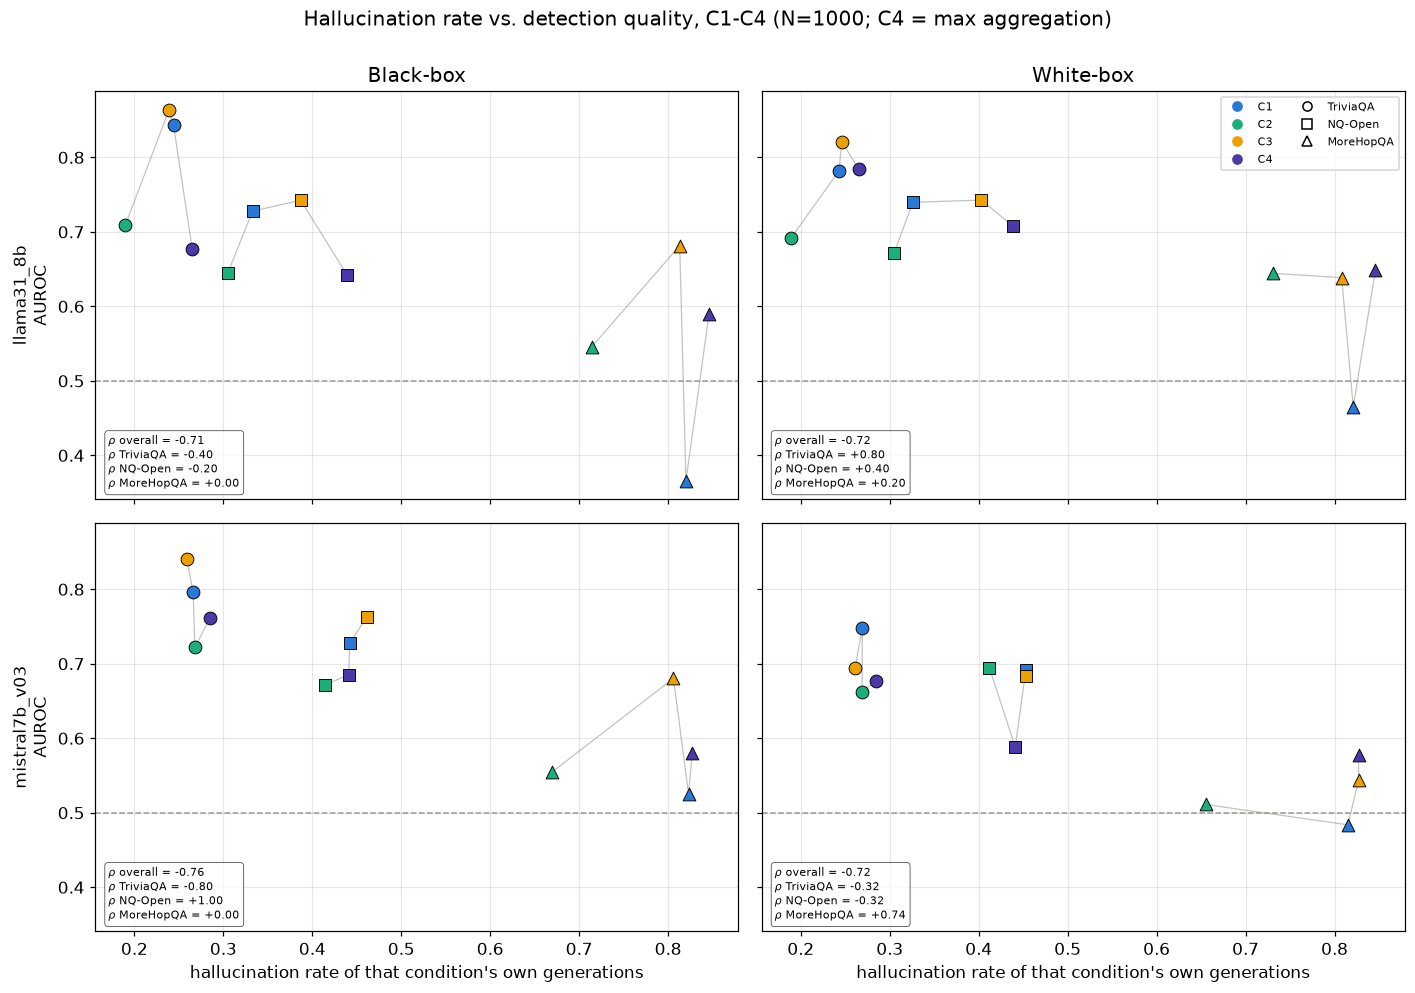

In [31]:
from matplotlib.lines import Line2D

DATASET_MARKERS = {"triviaqa": "o", "nqopen": "s", "morehopqa": "^"}


def rho_of(model_label, signal, scope):
    row = df_hr_corr[(df_hr_corr["model"] == model_label) & (df_hr_corr["signal"] == signal)
                     & (df_hr_corr["scope"] == scope)]
    return float(row["spearman_rho"].iloc[0])


def plot_hr_vs_auroc_scatter():
    fig, axes = plt.subplots(len(MODEL_TAGS), len(SIGNALS), figsize=(13, 9), sharex=True, sharey=True)
    for i, model_tag in enumerate(MODEL_TAGS):
        model_label = MODEL_LABELS[model_tag]
        for j, signal in enumerate(SIGNALS):
            ax = axes[i, j]
            sub_panel = df_hr_auroc[(df_hr_auroc["model"] == model_label)
                                    & (df_hr_auroc["signal"] == signal)]
            for dataset in DATASETS:
                sub = sub_panel[sub_panel["dataset"] == dataset]
                for _, r in sub.iterrows():
                    ax.scatter(r["hallucination_rate"], r["auroc"], marker=DATASET_MARKERS[dataset],
                               s=70, color=COND_COLORS[r["condition"]], edgecolor="black",
                               linewidth=0.6, zorder=3)
                # Line joining C1->C4 of one dataset: shows the within-dataset trend
                # the per-dataset rho quantifies.
                sub_sorted = sub.sort_values("hallucination_rate")
                ax.plot(sub_sorted["hallucination_rate"], sub_sorted["auroc"],
                        color=CHANCE_COLOR, lw=0.8, alpha=0.6, zorder=1)

            ax.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1)
            txt = (f"$\\rho$ overall = {rho_of(model_label, signal, 'overall'):+.2f}\n"
                   + "\n".join(f"$\\rho$ {DATASET_LABELS[ds]} = {rho_of(model_label, signal, ds):+.2f}"
                                for ds in DATASETS))
            ax.text(0.02, 0.02, txt, transform=ax.transAxes, fontsize=7.5, va="bottom",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, linewidth=0.5))
            if i == 0:
                ax.set_title(SIGNAL_LABELS[signal])
            if i == len(MODEL_TAGS) - 1:
                ax.set_xlabel("hallucination rate of that condition's own generations")
            if j == 0:
                ax.set_ylabel(f"{model_label}\nAUROC")

    cond_handles = [Line2D([0], [0], marker="o", ls="none", color=COND_COLORS[c], label=c)
                    for c in ["C1", "C2", "C3", "C4"]]
    ds_handles = [Line2D([0], [0], marker=DATASET_MARKERS[ds], ls="none", color="none",
                         markerfacecolor="none", markeredgecolor="black", label=DATASET_LABELS[ds])
                  for ds in DATASETS]
    axes[0, 1].legend(handles=cond_handles + ds_handles, fontsize=7.5, ncol=2, loc="upper right")
    fig.suptitle("Hallucination rate vs. detection quality, C1-C4 (N=1000; C4 = max aggregation)", y=1.0)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, "hallucination_rate_vs_auroc_scatter.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


plot_hr_vs_auroc_scatter()

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/hallucination_rate_vs_auroc_bars_8b.png


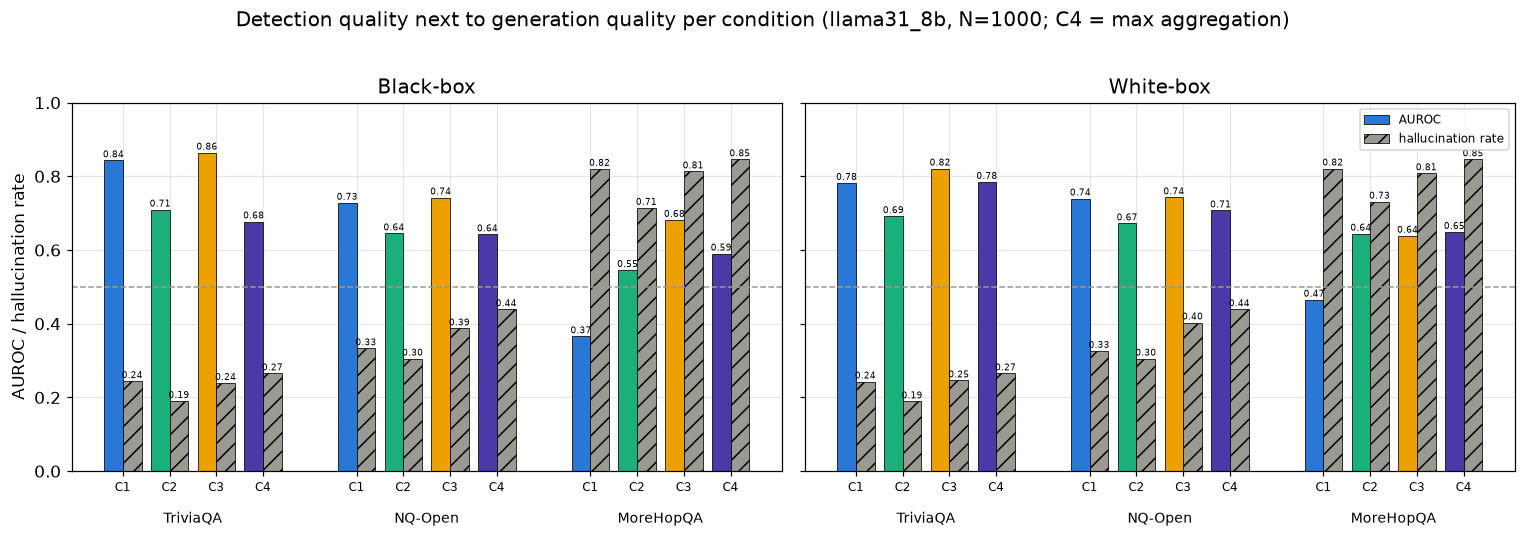

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/hallucination_rate_vs_auroc_bars_mistral.png


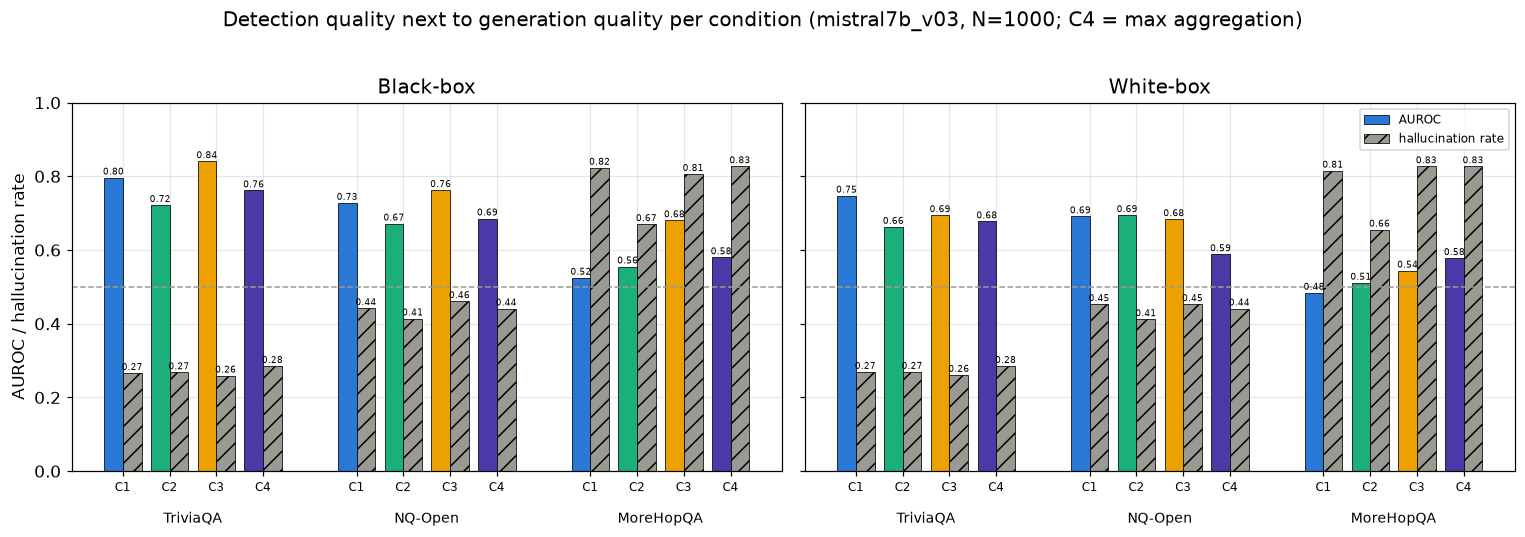

In [32]:
HRATE_COLOR = "#9a9992"


def plot_hr_vs_auroc_bars(model_tag, model_label):
    """Per-condition readout: AUROC next to the hallucination rate it was measured on."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    for ax, signal in zip(axes, SIGNALS):
        sub_panel = df_hr_auroc[(df_hr_auroc["model"] == model_label)
                                & (df_hr_auroc["signal"] == signal)]
        xs, labels = [], []
        for i, dataset in enumerate(DATASETS):
            for j, key in enumerate(HR_CONDS):
                cond = HR_COND_LABELS[key]
                x = i * (len(HR_CONDS) + 1) + j          # +1 leaves a gap between datasets
                r = sub_panel[(sub_panel["dataset"] == dataset) & (sub_panel["condition"] == cond)].iloc[0]
                ax.bar(x - 0.2, r["auroc"], width=0.4, color=COND_COLORS[cond],
                       edgecolor="black", linewidth=0.5,
                       label="AUROC" if (i == 0 and j == 0) else None)
                ax.bar(x + 0.2, r["hallucination_rate"], width=0.4, color=HRATE_COLOR,
                       edgecolor="black", linewidth=0.5, hatch="//",
                       label="hallucination rate" if (i == 0 and j == 0) else None)
                ax.annotate(f"{r['auroc']:.2f}", (x - 0.2, r["auroc"]), textcoords="offset points",
                            xytext=(0, 2), ha="center", fontsize=6)
                ax.annotate(f"{r['hallucination_rate']:.2f}", (x + 0.2, r["hallucination_rate"]),
                            textcoords="offset points", xytext=(0, 2), ha="center", fontsize=6)
                xs.append(x)
                labels.append(cond)
            ax.text(i * (len(HR_CONDS) + 1) + 1.5, -0.14, DATASET_LABELS[dataset],
                    ha="center", fontsize=9, transform=ax.get_xaxis_transform())

        ax.axhline(0.5, color=CHANCE_COLOR, ls="--", lw=1)
        ax.set_xticks(xs)
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylim(0, 1.0)
        ax.set_title(SIGNAL_LABELS[signal])
    axes[0].set_ylabel("AUROC / hallucination rate")
    axes[1].legend(fontsize=8, loc="upper right")
    fig.suptitle(f"Detection quality next to generation quality per condition "
                 f"({model_label}, N=1000; C4 = max aggregation)", y=1.02)
    fig.tight_layout()

    png_path = os.path.join(FIGURES_DIR, f"hallucination_rate_vs_auroc_bars_{model_tag}.png")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved -> {png_path}")
    plt.show()


for model_tag in MODEL_TAGS:
    plot_hr_vs_auroc_bars(model_tag, MODEL_LABELS[model_tag])

**Notes — Section 8**

- **The two axes are genuinely different quantities.** A condition can produce the best answers and the worst detector at the same time; the bar figure is the place to check that per condition, the scatter the place to see the pattern.
- **Across datasets the relationship is strongly negative** and mostly restates task difficulty: MoreHopQA hallucinates at 0.65–0.85 and detects near chance, TriviaQA hallucinates at 0.19–0.29 and detects at 0.80+. Do not read the overall ρ as "hallucinating less makes a model easier to audit" — it is the dataset effect.
- **Within a dataset the sign is not stable**, which is the point of reporting the per-dataset ρ separately. On MoreHopQA the condition with the *lowest* hallucination rate (C2, holistic CoT) is one of the *weakest* detectors, while C4 has the highest rate and the strongest black-box signal — generation quality and detectability pull apart exactly where the task is hardest.
- Within-dataset ρ is computed on 4 points (C1–C4). It is a direction, not a test; the `p_value` column in the correlation CSV is only meaningful for the `overall` rows (12 points).
- All rates are the condition's own label rate on its own generations, which is why they differ between C1–C4 in the same cell. Black-box and white-box rates for the same condition are close but not identical (separate runs) — except C4, where both boxes share the same decoded chain.